# 35b · EDM: score·DDPM·DDIM을 σ 하나로 다시 쓰기

**이번 질문:** 33번의 $\sigma$ 사다리, 34–35번의 $\bar\alpha_t$ 일정, 35번의 결정적 DDIM 걸음은 서로 다른 모델일까요? 셋을 좌표 하나로 다시 쓰면 무엇이 "같은 것"이고 무엇이 "우리가 고른 설계"였는지 갈라집니다.

33번은 $x=x_0+\sigma\epsilon$의 사다리를 내려왔고, 34번은 $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$으로 신호까지 줄였습니다. 두 식은 달라 보이지만, 34번 식을 $\sqrt{\bar\alpha_t}$로 나누면 **글자 하나 다르지 않고** 33번의 식이 됩니다.
그러면 남는 차이는 "$\sigma$를 어떤 순서로 지나가는가" 하나뿐입니다. 이 노트북은 그 좌표 위에서 신경망을 감싸는 방법(preconditioning), 손실의 가중, 시간 격자, 그리고 샘플링을 **미분방정식 풀기**로 보는 관점을 차례로 만듭니다.
$\sigma$ 통일과 Tweedie → preconditioning → 손실 가중과 $\sigma$ 분포 → ODE와 Euler·Heun → 확률적 샘플러 순서로 갑니다.

- 준비물: [32](32_score_matching.ipynb) 3절의 $q_\sigma$와 Tweedie, [33](33_ncsn.ipynb) 1절의 $\sigma$ 사다리, [34](34_diffusion_forward.ipynb) 1·3·5절의 $\bar\alpha_t$·$\epsilon$ 예측·SNR, [35](35_diffusion_reverse.ipynb) 3절의 DDIM, [23](23_latent_mixture_em.ipynb) 5절의 `mix_denoiser`, [12](../02_연결/12_gaussian_information.ipynb)의 Gaussian, [01](../00_기초/01_gradients_and_learning.ipynb)의 미분, [03](../00_기초/03_perceptron_to_mlp.ipynb)·[04](../00_기초/04_optimizers.ipynb)의 MLP backward와 Adam.
- 도착점: Tweedie 관계·preconditioning 계수·손실 가중·$\sigma$ 분포·$\rho$ 시간 격자·Heun 샘플러를 손계산과 정확한 denoiser로 검산하고, 같은 학습 모델을 네 가지 샘플러로 비교합니다.
- 다음 연결: 36 flow matching은 "잡음에서 데이터까지 직선으로 가는 속도장"을 회귀로 배웁니다. 이 노트북의 ODE 관점이 그대로 쓰입니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 모든 모델을 $x=x_0+\sigma\epsilon$ 한 좌표로 옮기면 남는 차이는 $\sigma$ 일정뿐이고, score와 최적 복원은 $\nabla_x\log q_\sigma(x)=\dfrac{D(x;\sigma)-x}{\sigma^2}$ 한 줄로 묶입니다. 코드로는 `(denoised - x) / sigma ** 2`.
2. 신경망에게 $D$를 직접 내라고 하지 않습니다. $D(x;\sigma)=c_{skip}(\sigma)\,x+c_{out}(\sigma)\,F(c_{in}(\sigma)x;\,c_{noise}(\sigma))$로 감싸면 $F$가 보는 입력과 맞혀야 할 타깃이 $\sigma$와 상관없이 규모 1이 되고, 손실 가중 $\lambda(\sigma)=1/c_{out}(\sigma)^2$가 모든 $\sigma$에 같은 무게를 줍니다.
3. 샘플링은 $\dfrac{dx}{d\sigma}=\dfrac{x-D(x;\sigma)}{\sigma}$를 $\sigma_{max}$에서 0까지 **적분하는 일**입니다. DDIM은 이 식의 Euler 걸음이고, 끝점 기울기로 한 번 더 고치는 Heun은 같은 $D$ 호출 수에서 훨씬 정확합니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/edm_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(1절부터: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/edm_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.edm_plots import (
    plot_unified_sigma, plot_preconditioning, plot_loss_weighting, plot_training_loss,
    plot_ode_paths, plot_solver_error, plot_sampler_grid, plot_sampler_metrics, plot_variants,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· EDM 준비 완료")

NumPy 2.4.6 · EDM 준비 완료


### 📎 이 노트북의 예시: 1·2차원 두 봉우리 혼합, 고정 예시 7, MNIST PCA-32 좌표

- **1차원 두 봉우리 혼합.** 23번부터 쓰는 공통 상황입니다. 비율 $\pi=(0.3,0.7)$, 평균 $\mu=(-2,2)$, 표준편차 $\sigma=(0.5,1)$인 두 Gaussian의 혼합입니다. 잡음을 더한 뒤의 밀도·score·최적 복원이 모두 닫힌식이라 1·2절의 손계산과 검산에 씁니다.
- **2차원 두 봉우리 혼합.** 4절의 주인공입니다. 정확한 $D(x;\sigma)$를 알고 있으므로 미분방정식을 "정답을 아는 채로" 풀 수 있고, 그래서 **적분기의 오차와 모델의 오차를 따로 잴 수 있습니다.**
- **고정 예시 7.** 00번부터 쓴 MNIST 예시 10장 중 7입니다. 2절에서 "신경망이 실제로 보는 입력"이 어떻게 생겼는지 눈으로 봅니다. 학습에는 쓰지 않습니다.
- **MNIST PCA-32 좌표.** 앞 5,000장을 11번 3절의 고유분해로 32차원 좌표로 줄인 것입니다. 5절에서 이 좌표 위의 EDM 모델을 학습하고 네 가지 샘플러로 숫자를 만듭니다.

> **용어**
>
> - **EDM**: Karras 등(2022)이 붙인 이름으로, 여러 diffusion 모델을 하나의 설계 공간에 늘어놓고 **각 선택을 따로 고를 수 있게** 정리한 논문입니다. 새 모델이라기보다 "이미 있던 것들의 좌표계"에 가깝습니다.
> - **최적 복원(denoiser)** $D(x;\sigma)=\mathbb E[x_0\mid x_0+\sigma\epsilon=x]$: 잡음 섞인 점 $x$를 보고 원래 점을 되짚는 조건부 평균. 혼합이면 닫힌식입니다 (23번 5절). 코드에서는 `mix_denoiser(x, sigma)`.
> - **$\sigma_{data}$**: 데이터 자체의 표준편차. Karras 논문은 화소를 $[-1,1]$로 옮긴 이미지에서 $\sigma_{data}=0.5$를 씁니다(표 1). 아래 규약 셀의 `SIGMA_DATA`가 그것입니다.
> - **MNIST**: 28×28 흑백 손글씨 숫자 이미지 데이터셋. 여기서는 32개 좌표로 줄여 학습하고, 만든 좌표를 다시 이미지로 되돌려 봅니다.

아래 네 셀은 실행만 하고 넘어가도 됩니다. 혼합 함수는 23번(과 32·34번)의 정의를 그대로 짧게 다시 쓴 것이고, `sigma` 인자를 주면 잡음이 섞인 뒤의 분포가 됩니다 (32번 3절).

> **코드**
>
> - `x[:, None]`: `(N,)`을 `(N, 1)`로 세워 `(2,)`짜리 성분 배열과 브로드캐스팅. 결과는 `(N, 2)` = 점마다 성분 두 개.
> - `terms.max(axis=1, keepdims=True)`: 행마다 최댓값을 `(N, 1)`로 남겨 빼기 쉽게 합니다. 지수가 넘치지 않게 하는 02번 8절의 안정화입니다.
> - `rng.choice(2, size=n, p=MIX_PI)`: 0 또는 1을 확률 `MIX_PI`로 n번 뽑습니다. 잠재 성분 $z$를 먼저 뽑는 ancestral sampling (23번 5절).
> - `np.linalg.solve(C, d.T).T`: 관측마다 $C^{-1}d$를 한 번에 (12번 2절). `np.linalg.slogdet(C)[1]`은 $\log\det C$.

In [2]:
SIGMA_DATA = 0.5                                                     # 데이터의 표준편차 (Karras 표 1: [−1, 1] 이미지)
SIGMA_MIN, SIGMA_MAX = 0.002, 80.0                                   # 샘플러가 지나가는 σ 의 양 끝 (논문 표 1)
RHO = 7.0                                                            # 시간 격자의 모양을 정하는 지수 (4절)
P_MEAN, P_STD = -1.2, 1.2                                            # 학습용 σ 를 뽑는 ln σ 의 평균·표준편차 (3절)
MIX_PI = np.array([0.3, 0.7])                                        # (2,): 1차원 혼합의 비율 π_k
MIX_MU = np.array([-2.0, 2.0])                                       # (2,): 성분 평균 μ_k
MIX_SIGMA = np.array([0.5, 1.0])                                     # (2,): 성분 표준편차 σ_k
MIX2_PI = np.array([0.4, 0.6])                                       # (2,): 2차원 혼합의 비율
MIX2_MU = np.array([[-2.0, 0.0], [2.0, 1.0]])                        # (2, 2): 성분 평균 (행 = 성분)
MIX2_COV = np.array([[[0.6, 0.2], [0.2, 0.5]], [[0.4, -0.1], [-0.1, 0.8]]])   # (2, 2, 2): 성분 공분산 Σ_k
print("σ_data", SIGMA_DATA, "· σ 범위", SIGMA_MIN, "–", SIGMA_MAX, "· ρ", RHO, "· ln σ ~ N(", P_MEAN, ",", P_STD, "²)")

σ_data 0.5 · σ 범위 0.002 – 80.0 · ρ 7.0 · ln σ ~ N( -1.2 , 1.2 ²)


In [3]:
def mix_log_terms(x, sigma=0.0):
    """성분별 log π_k + log N(x; μ_k, σ_k² + σ²). sigma 는 더한 잡음의 표준편차(0이면 원래 혼합). x: (N,) → (N, 2)."""
    variances = MIX_SIGMA ** 2 + sigma ** 2                          # (2,): 성분 분산
    squared = (x[:, None] - MIX_MU) ** 2 / variances                 # (N, 2): 표준화한 제곱 거리
    return np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * variances) + squared)


def mix_logpdf(x, sigma=0.0):
    """23번 1절: log q_σ(x) = logsumexp_k [log π_k + log N(x; μ_k, σ_k² + σ²)]. x: (N,) → (N,)."""
    terms = mix_log_terms(x, sigma)
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값 (안정화)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix_responsibility(x, sigma=0.0):
    """23번 2절: r_k(x) = softmax_k 로그 항. x: (N,) → (N, 2), 행 합 1."""
    terms = mix_log_terms(x, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, 2)
    return shifted / shifted.sum(axis=1, keepdims=True)


def mix_sample(n, rng):
    """23번 5절 ancestral sampling: z ~ π 를 뽑고 x ~ N(μ_z, σ_z²). n: 개수 → (n,)."""
    z = rng.choice(2, size=n, p=MIX_PI)                              # (n,): 성분 번호
    return MIX_MU[z] + MIX_SIGMA[z] * rng.normal(size=n)

In [4]:
def mix_denoiser(x_noisy, sigma):
    """23번 5절: 최적 복원 E[x₀ | x̃] = Σ_k r_k^σ(x̃) [μ_k + σ_k²/(σ_k² + σ²) (x̃ − μ_k)]. x_noisy: (N,) → (N,)."""
    r = mix_responsibility(x_noisy, sigma)                           # (N, 2): 분산 σ_k² + σ² 의 책임확률
    shrink = MIX_SIGMA ** 2 / (MIX_SIGMA ** 2 + sigma ** 2)          # (2,): 성분별로 x̃ 를 μ_k 쪽으로 당기는 비율
    return np.sum(r * (MIX_MU + shrink * (x_noisy[:, None] - MIX_MU)), axis=1)


def mix_score_noisy(x, sigma):
    """32번 3절: 잡음을 더한 혼합 q_σ 의 score Σ_k r_k^σ(x) (μ_k − x)/(σ_k² + σ²). x: (N,) → (N,)."""
    r = mix_responsibility(x, sigma)
    return np.sum(r * (MIX_MU - x[:, None]) / (MIX_SIGMA ** 2 + sigma ** 2), axis=1)


def mix2_log_terms(X, sigma=0.0):
    """2차원 성분별 log π_k + log N(x; μ_k, Σ_k + σ²I). X: (N, 2) → (N, 2)."""
    terms = np.zeros((len(X), 2))
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)            # (2, 2): 잡음을 더한 공분산
        difference = X - MIX2_MU[k]                                  # (N, 2): x − μ_k
        squared = np.sum(difference * np.linalg.solve(covariance, difference.T).T, axis=1)   # (N,): (x−μ)ᵀ Σ⁻¹ (x−μ)
        terms[:, k] = np.log(MIX2_PI[k]) - 0.5 * (2 * np.log(2 * np.pi) + np.linalg.slogdet(covariance)[1] + squared)
    return terms

In [5]:
def mix2_logpdf(X, sigma=0.0):
    """2차원 혼합의 log q_σ(x) (23번 1절). X: (N, 2) → (N,)."""
    terms = mix2_log_terms(X, sigma)
    biggest = terms.max(axis=1, keepdims=True)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix2_responsibility(X, sigma=0.0):
    """2차원 혼합의 책임확률 (23번 2절). X: (N, 2) → (N, 2)."""
    terms = mix2_log_terms(X, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))
    return shifted / shifted.sum(axis=1, keepdims=True)


def mix2_sample(n, rng):
    """2차원 ancestral sampling: z ~ π, x = μ_z + L_z ε (12번 1절의 Cholesky). n: 개수 → (n, 2)."""
    z = rng.choice(2, size=n, p=MIX2_PI)                             # (n,)
    epsilon = rng.normal(size=(n, 2))                                # (n, 2): 독립 표준정규
    L = np.linalg.cholesky(MIX2_COV)                                 # (2, 2, 2): 성분마다 Σ_k = L_k L_kᵀ
    return MIX2_MU[z] + np.einsum("nij,nj->ni", L[z], epsilon)


def mix2_denoiser(X_noisy, sigma):
    """23번 5절의 2차원 판: E[x₀ | x̃] = Σ_k r_k^σ [μ_k + Σ_k (Σ_k + σ²I)⁻¹ (x̃ − μ_k)]. X_noisy: (N, 2) → (N, 2)."""
    r = mix2_responsibility(X_noisy, sigma)                          # (N, 2)
    out = np.zeros_like(X_noisy)
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)
        pulled = (MIX2_COV[k] @ np.linalg.solve(covariance, (X_noisy - MIX2_MU[k]).T)).T   # (N, 2): 성분별 수축
        out += r[:, k:k + 1] * (MIX2_MU[k] + pulled)
    return out

📎 **참고** · 아래 셀은 MNIST를 읽고 앞 5,000장을 32차원 좌표로 줄입니다. 11번 3절처럼 평균을 뺀 뒤 공분산의 고유벡터 상위 32개를 골라 그 방향의 좌표만 남기고, 전체 표준편차 하나로 나눕니다(공통 규약의 `mnist_Z`).
그 뒤 **$\sigma_{data}=0.5$ 규모로 옮긴 좌표** `mnist_X0 = SIGMA_DATA * mnist_Z`를 따로 둡니다. 전처리 계수와 $\sigma$ 분포가 모두 "데이터의 표준편차가 $\sigma_{data}$"라는 약속 위에서 만들어지기 때문입니다.

> **코드**
>
> - `np.linalg.eigh(C)`: 대칭 행렬의 고유값·고유벡터를 **오름차순**으로 돌려줍니다. `[:, ::-1]`로 열 순서를 뒤집어 큰 고유값부터 씁니다 (11번 3절).
> - `Z.std()`: 축을 주지 않으면 배열 전체의 표준편차 숫자 하나. 좌표마다 나누면 작은 방향이 부풀려지므로 하나로만 나눕니다.

In [6]:
# 쓰는 것: SIGMA_DATA (📎 규약 셀)
mnist_examples, mnist_labels = load_examples(download=True)          # (10, 28, 28) 고정 예시, (10,) 정답 숫자
mnist_7 = mnist_examples[7]                                          # (28, 28): 예시 7 한 장. 값은 0–1 잉크
mnist_X_all, mnist_y_all, mnist_X_test, mnist_y_test = load_mnist(download=True)
mnist_X = mnist_X_all[:5000]                                         # (5000, 784): 학습에 쓰는 앞 5,000장
mnist_mu = mnist_X.mean(axis=0)                                      # (784,): 평균 이미지
mnist_centered = mnist_X - mnist_mu                                  # (5000, 784)
mnist_eigvals, mnist_eigvecs = np.linalg.eigh(mnist_centered.T @ mnist_centered / len(mnist_X))   # 공분산의 고유분해 (11번 3절)
mnist_Q = mnist_eigvecs[:, ::-1][:, :32]                             # (784, 32): 큰 고유값 32개의 방향
mnist_scale = float((mnist_centered @ mnist_Q).std())                # 숫자 하나: PCA 좌표 전체의 표준편차
mnist_Z = (mnist_centered @ mnist_Q) / mnist_scale                   # (5000, 32): 표준편차 1 로 맞춘 좌표 (공통 규약)
mnist_X0 = SIGMA_DATA * mnist_Z                                      # (5000, 32): σ_data = 0.5 규모로 옮긴 학습 데이터
mnist_pixel_std = float((2 * mnist_X - 1).std())                     # [−1, 1] 화소의 표준편차 (논문의 σ_data = 0.5 와 비교)
print("PCA 좌표", mnist_Z.shape, "· 좌표 표준편차", round(float(mnist_X0.std()), 4),
      "· [−1, 1] 화소의 표준편차", round(mnist_pixel_std, 3))

PCA 좌표 (5000, 32) · 좌표 표준편차 0.5 · [−1, 1] 화소의 표준편차 0.615


In [7]:
def decode_pca(Z):
    """PCA-32 좌표를 28×28 이미지로 되돌립니다: X = (Z · scale) Qᵀ + μ. Z: (N, 32) → (N, 28, 28), 0–1로 자름."""
    # 쓰는 것: mnist_scale, mnist_Q, mnist_mu (📎 PCA 셀)
    flat = (Z * mnist_scale) @ mnist_Q.T + mnist_mu                  # (N, 784)
    return np.clip(flat, 0, 1).reshape(len(Z), 28, 28)

In [8]:
# 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA, SIGMA_DATA (📎 규약 셀) · mix_logpdf, mix_denoiser, mix_sample, mix2_logpdf, mix2_denoiser, mix2_sample (📎 혼합 셀) · mnist_X0 (📎 PCA 셀)
check_x = np.linspace(-12, 12, 24001)                                # (24001,): 적분 격자
np.testing.assert_allclose(np.trapezoid(np.exp(mix_logpdf(check_x)), check_x), 1.0, atol=1e-8)   # 검산: 밀도의 적분 = 1
probe_noisy = np.array([-1.0, 0.0, 1.5])                             # (3,): 최적 복원을 시험할 점
np.testing.assert_allclose(mix_denoiser(probe_noisy, 1e-7), probe_noisy, atol=1e-6)              # 검산: σ → 0 이면 되돌릴 것이 없어 항등
np.testing.assert_allclose(mix_denoiser(probe_noisy, 300.0), np.sum(MIX_PI * MIX_MU), atol=1e-3)  # 검산: σ 가 크면 전체 평균 0.8 하나로
mix_sigma_data = float(np.sqrt(np.sum(MIX_PI * (MIX_SIGMA ** 2 + MIX_MU ** 2)) - np.sum(MIX_PI * MIX_MU) ** 2))
mix2_sigma_data = float(mix2_sample(200000, np.random.default_rng(35)).std())
np.testing.assert_allclose(mix_sample(200000, np.random.default_rng(23)).std(), mix_sigma_data, rtol=0.02)  # 검산: 표본 표준편차 = 닫힌식
check_X = np.array([[-1.0, 0.5], [0.4, -0.3], [1.2, 1.1], [-0.6, -1.4]])       # (4, 2): 2차원 복원을 시험할 점
check_step = 1e-4                                                    # 중심차분의 한 걸음
for check_sigma in [0.2, 1.0, 3.0]:
    gaps = [mix2_logpdf(check_X + check_step * axis, check_sigma) - mix2_logpdf(check_X - check_step * axis, check_sigma)
            for axis in np.eye(2)]                                   # 좌표마다 (4,): 앞뒤 log q_σ 의 차
    check_score = np.stack(gaps, axis=1) / (2 * check_step)          # (4, 2): 중심차분으로 잰 ∇log q_σ
    check_tweedie = check_X + check_sigma ** 2 * check_score         # (4, 2): Tweedie 로 되짚은 x₀
    np.testing.assert_allclose(mix2_denoiser(check_X, check_sigma), check_tweedie, rtol=1e-6)   # 검산: 2차원 최적 복원 = x + σ²∇log q_σ
assert abs(float(mnist_X0.std()) - SIGMA_DATA) < 1e-12, "MNIST 좌표는 표준편차가 σ_data 가 되게 맞추었습니다"
print("데이터의 표준편차 σ_data · 1차원 혼합", round(mix_sigma_data, 4), "· 2차원 혼합", round(mix2_sigma_data, 4),
      "· MNIST 좌표", SIGMA_DATA)

데이터의 표준편차 σ_data · 1차원 혼합 2.0335 · 2차원 혼합 1.6224 · MNIST 좌표 0.5


🔍 **확인** · 혼합의 밀도가 1로 적분되고, 최적 복원은 $\sigma\to0$에서 항등, $\sigma$가 아주 크면 전체 평균 $\sum_k\pi_k\mu_k=0.8$ 하나로 갑니다. 되돌릴 정보가 없으면 평균을 답하는 것이 최선이기 때문입니다.
세 상황의 $\sigma_{data}$도 재 두었습니다. 1차원 혼합은 2.03, 2차원 혼합은 1.62, MNIST 좌표는 우리가 0.5로 맞춘 값입니다. $[-1,1]$ 화소의 표준편차가 0.62쯤이라 논문의 $\sigma_{data}=0.5$와 가깝다는 것도 확인할 수 있습니다.

## 🔑 1. $\sigma$ 하나로 통일: 세 모델은 같은 좌표 위에 있습니다

**이 절에서 가져갈 것:** 34번의 $x_t$를 $\sqrt{\bar\alpha_t}$로 나누면 $x_t/\sqrt{\bar\alpha_t}=x_0+\sigma(t)\epsilon$, $\sigma(t)=\sqrt{(1-\bar\alpha_t)/\bar\alpha_t}$가 되어 33번의 좌표와 **글자 하나 다르지 않습니다.** 그 좌표에서 score와 최적 복원은 $\nabla_x\log q_\sigma(x)=\dfrac{D(x;\sigma)-x}{\sigma^2}$ 하나로 묶입니다.

세 노트북이 서로 다른 식을 썼습니다. 33번은 $x=x_0+\sigma\epsilon$, 34–35번은 $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$입니다. 둘이 정말 다른 모델이라면 배운 것을 옮겨 쓸 수 없습니다.
그런데 34번 식의 양변을 $\sqrt{\bar\alpha_t}$로 나누면 왼쪽은 그냥 "좌표를 늘려 본 것"이고 오른쪽은 33번의 식입니다. 즉 **VP는 VE를 확대·축소해서 본 것**이고, 학습한 모델도 그대로 옮겨집니다.

> **용어**
>
> - **VE(variance exploding, 분산 폭발)**: 신호 $x_0$는 그대로 두고 잡음의 분산 $\sigma^2$만 키우는 방식 (33번). $x=x_0+\sigma\epsilon$이라 $\sigma$가 커지면 전체 분산이 끝없이 커집니다.
> - **VP(variance preserving, 분산 보존)**: 신호를 $\sqrt{\bar\alpha_t}$배로 줄이고 잡음을 더해 전체 분산을 1로 유지하는 방식 (34번 1절).
> - **스케일 $s(t)$**: $x_t=s(t)\,[\,x_0+\sigma(t)\epsilon\,]$로 쓸 때 앞에 붙는 계수. VE는 $s(t)=1$, VP는 $s(t)=\sqrt{\bar\alpha_t}$입니다. 즉 모델의 차이는 $(s,\sigma)$ 두 함수를 어떻게 골랐는가로 정리됩니다.
> - **Tweedie 항등(Tweedie's formula)**: 잡음 섞인 점에서의 score와 조건부 평균을 잇는 관계 (32번 3절). "score를 안다"와 "최적 복원을 안다"가 같은 말이라는 뜻입니다.

$x_0$와 $\epsilon$은 $(N,D)$, $\sigma$는 숫자 하나 또는 표본마다 하나인 $(N,1)$입니다. 좌표 $i$마다 같은 계수를 쓰므로 브로드캐스팅으로 곱하면 됩니다.

$$x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon
\quad\Longleftrightarrow\quad
\underbrace{\frac{x_t}{\sqrt{\bar\alpha_t}}}_{\text{좌표를 } 1/s \text{ 배}}=x_0+\underbrace{\sqrt{\frac{1-\bar\alpha_t}{\bar\alpha_t}}}_{\sigma(t)}\,\epsilon.$$

이제 잡음이 섞인 뒤의 분포를 $q_\sigma(x)=\int p(x_0)\,\mathcal N(x;x_0,\sigma^2I)\,dx_0$라 씁니다 (32번 3절). 로그를 $x$로 미분하면 적분 안의 Gaussian만 미분되고, $\nabla_x\mathcal N(x;x_0,\sigma^2I)=\mathcal N\cdot\frac{x_0-x}{\sigma^2}$이므로

$$\nabla_x\log q_\sigma(x)=\frac{1}{q_\sigma(x)}\int p(x_0)\,\mathcal N(x;x_0,\sigma^2I)\,\frac{x_0-x}{\sigma^2}\,dx_0
=\mathbb E\!\left[\frac{x_0-x}{\sigma^2}\,\Big|\,x\right]=\boxed{\;\frac{D(x;\sigma)-x}{\sigma^2}\;}$$

입니다. 가중치가 $p(x_0)\mathcal N/q_\sigma$ = 사후확률이므로 적분이 조건부 평균이 되고, $\mathbb E[x_0\mid x]$가 곧 $D(x;\sigma)$입니다. 같은 예측을 34번의 $\epsilon$ 자로 옮기면 $\hat\epsilon=(x-D)/\sigma$이고 $\nabla\log q_\sigma=-\hat\epsilon/\sigma$입니다. **세 가지는 같은 것의 세 얼굴이고, 서로 나눗셈 한 번으로 오갑니다.**

| 모델 | 학습·샘플링 좌표 | $s(t)$ | $\sigma(t)$ | 신경망이 내는 것 |
|---|---|---|---|---|
| NCSN (33번) | $x=x_0+\sigma_i\epsilon$ | $1$ | 기하 사다리 $\sigma_i$ | score $s_\theta(x,\sigma)$ |
| DDPM (34·35번) | $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$ | $\sqrt{\bar\alpha_t}$ | $\sqrt{(1-\bar\alpha_t)/\bar\alpha_t}$ | $\hat\epsilon$ |
| DDIM (35번 3절) | 위와 같음 | $\sqrt{\bar\alpha_t}$ | 위와 같음 | $\hat\epsilon$ (결정적 걸음) |
| EDM (이 노트북) | $x=x_0+\sigma\epsilon$ | $1$ | $\rho$ 격자 (4절) | $D(x;\sigma)$ |

**손계산 (1)** 34번 3절의 예 $\bar\alpha_t=0.64$: $s=\sqrt{0.64}=0.8$, $\sigma=\sqrt{0.36/0.64}=0.75$입니다. 같은 점을 $x_t=1.1$로 보든 $x_t/s=1.375$로 보든 담긴 정보는 같습니다.

**손계산 (2)** 데이터가 $\mathcal N(0,1)$ 하나뿐이고 $\sigma=1$이라면, 최적 복원은 12번 4절의 MAP 수축식(관측 하나면 $\tau^2/(\tau^2+\sigma^2)x$)과 같은 계산이라 $D(x;1)=\frac{1}{1+1}x$입니다. $x=2$에서 $D=1$이고, Tweedie로 만든 score는 $(1-2)/1^2=-1$입니다. 한편 $q_1=\mathcal N(0,2)$의 score는 $-x/2=-1$로 같습니다.

아래는 세 모델의 $\sigma$ 일정을 한 축에 올린 그림, 한 $\sigma$에서 $x$가 $D$로 당겨지는 그림, 그리고 $\sigma$ 세 값의 denoiser 곡선입니다.

> **코드** · `np.arange(18) / 17`: 0부터 1까지를 18칸으로 나눈 진행도. 걸음 수가 다른 세 일정을 같은 가로축에 겹치려고 씁니다.

In [9]:
# 쓰는 것: SIGMA_MIN, SIGMA_MAX, RHO (📎 규약 셀)
vp_T = 200                                                           # 34번의 걸음 수
vp_beta = np.concatenate([[0.0], np.linspace(1e-4, 0.02, vp_T)])     # (201,): 34번 1절의 선형 스케줄
vp_alpha_bar = np.cumprod(1 - vp_beta)                               # (201,): ᾱ_t (누적곱)
vp_sigma_axis = np.sqrt((1 - vp_alpha_bar[1:]) / vp_alpha_bar[1:])   # (200,): VP 를 σ 좌표로 옮긴 값
ncsn_sigma_axis = 3.0 * (0.1 / 3.0) ** (np.arange(10) / 9)           # (10,): 33번 1절의 기하 사다리
edm_sigma_axis = (SIGMA_MAX ** (1 / RHO) + np.arange(18) / 17 *      # (18,): 4절에서 만들 ρ 격자를 미리 한 줄로
                  (SIGMA_MIN ** (1 / RHO) - SIGMA_MAX ** (1 / RHO))) ** RHO
sigma_families = {"NCSN 사다리 (33번)": (np.arange(10) / 9, ncsn_sigma_axis),
                  "DDPM·DDIM (34·35번)": (np.arange(200) / 199, vp_sigma_axis[::-1]),
                  "EDM $\\rho$ 격자 (4절)": (np.arange(18) / 17, edm_sigma_axis)}
print("VP 의 σ 범위:", round(float(vp_sigma_axis[0]), 4), "–", round(float(vp_sigma_axis[-1]), 3),
      "· NCSN:", round(float(ncsn_sigma_axis[-1]), 2), "–", round(float(ncsn_sigma_axis[0]), 2),
      "· EDM:", SIGMA_MIN, "–", SIGMA_MAX)
print("손계산: ᾱ = 0.64 → s =", round(float(np.sqrt(0.64)), 4), ", σ =", round(float(np.sqrt(0.36 / 0.64)), 4))

VP 의 σ 범위: 0.01 – 2.562 · NCSN: 0.1 – 3.0 · EDM: 0.002 – 80.0
손계산: ᾱ = 0.64 → s = 0.8 , σ = 0.75


In [10]:
# 쓰는 것: mix_logpdf, mix_denoiser (📎 혼합 셀)
tweedie_x = np.linspace(-6, 6, 601)                                  # (601,): 밀도·곡선을 그릴 격자
tweedie_sigma = 1.0                                                  # 화살표 그림에서 쓸 잡음 크기
tweedie_pdf = np.exp(mix_logpdf(tweedie_x, tweedie_sigma))           # (601,): q_σ(x)
tweedie_points = np.array([-5.0, -1.5, 0.5, 5.0])                    # (4,): 화살표를 그릴 점
tweedie_denoised = mix_denoiser(tweedie_points, tweedie_sigma)       # (4,): 그 점들의 D(x;σ)
denoiser_sigmas = [0.2, 1.0, 4.0]                                    # 곡선을 볼 세 잡음 크기
denoiser_curves = [mix_denoiser(tweedie_x, sigma) for sigma in denoiser_sigmas]   # 세 개의 (601,)
print("σ =", tweedie_sigma, "· x =", tweedie_points, "→ D(x;σ) =", tweedie_denoised.round(3))
print("score = (D − x)/σ² =", ((tweedie_denoised - tweedie_points) / tweedie_sigma ** 2).round(3))

σ = 1.0 · x = [-5.  -1.5  0.5  5. ] → D(x;σ) = [-2.6   -1.713  1.051  3.5  ]
score = (D − x)/σ² = [ 2.4   -0.213  0.551 -1.5  ]


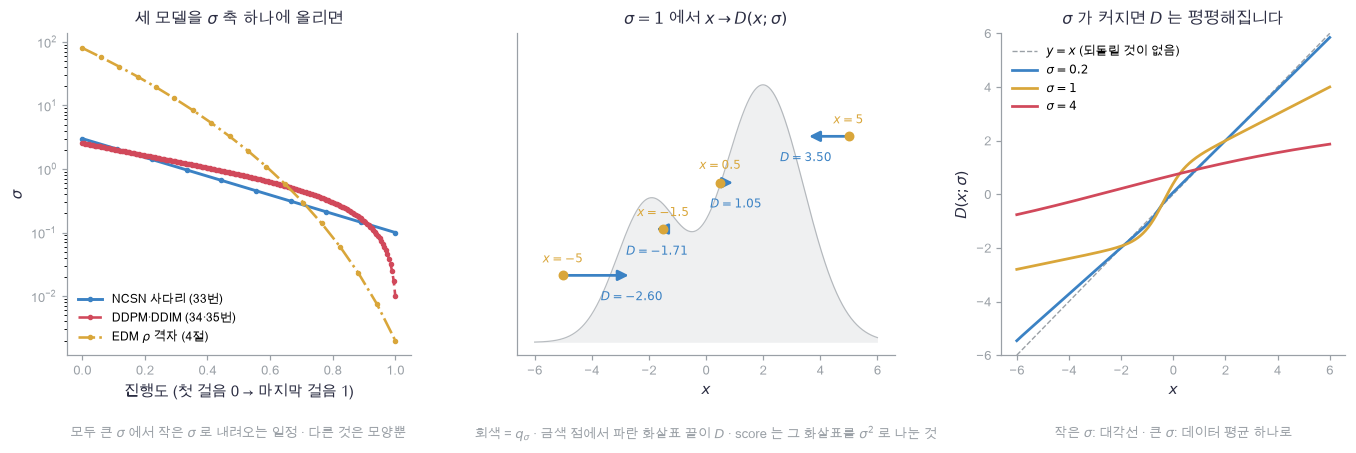

In [11]:
plot_unified_sigma(sigma_families, tweedie_x, tweedie_pdf, tweedie_sigma, tweedie_points, tweedie_denoised,
                   denoiser_sigmas, denoiser_curves)

🔍 **확인** · 왼쪽에서 세 일정이 모두 "큰 $\sigma$에서 작은 $\sigma$로 내려오는 곡선" 하나입니다. 다른 것은 시작·끝 값과 내려오는 모양뿐입니다. DDPM의 $\sigma$는 위로 $2.56$까지만 올라가는데, $T=200$·선형 $\beta$에서는 $\bar\alpha_T=0.132$라 신호가 완전히 지워지지 않기 때문입니다(34번 완성 예제에서 본 것과 같은 이야기). EDM은 $80$까지 올라갔다가 $0.002$까지 내려옵니다.
가운데에서 금색 점 $x$가 파란 화살표 끝 $D(x;\sigma)$로 당겨집니다. 데이터가 많은 쪽(회색 봉우리)으로 당겨지고, 봉우리에서 먼 $x=5$는 $1.5$만큼, 봉우리 근처의 $x=0.5$는 $0.55$만큼 움직입니다. 그 화살표를 $\sigma^2$으로 나눈 것이 score입니다. **"어디로 얼마나 당길까"와 "밀도가 어느 쪽으로 커지나"가 같은 질문입니다.**
오른쪽은 같은 $D$를 곡선으로 본 것입니다. $\sigma=0.2$에서는 거의 대각선($D\approx x$: 되돌릴 것이 거의 없음), $\sigma=4$에서는 거의 수평선($D\approx$ 데이터 평균: 되돌릴 정보가 없음)입니다. 그 사이의 $\sigma=1$에서만 곡선이 계단처럼 휘어 "어느 봉우리에서 왔는지"를 고릅니다.

아래 구현은 좌표 변환과 세 얼굴(score·$D$·$\hat\epsilon$) 사이의 변환입니다. 네 함수 모두 나눗셈 한 번짜리입니다.

In [12]:
def vp_to_sigma(alpha_bar_values):
    """VP 좌표를 σ 좌표로: x_t/√ᾱ_t = x₀ + σ(t) ε 이므로 σ(t) = √((1 − ᾱ_t)/ᾱ_t) (34번 1절의 ᾱ_t).
    alpha_bar_values: 숫자 하나 또는 (T+1,) → 같은 모양."""
    ab = np.asarray(alpha_bar_values, dtype=float)
    assert np.all(ab > 0), "ᾱ_t 가 0 보다 커야 σ 좌표로 나눌 수 있습니다"
    return np.sqrt((1 - ab) / ab)


def score_from_denoiser(x, denoised, sigma):
    """Tweedie 항등 (32번 3절): ∇_x log q_σ(x) = (D(x;σ) − x)/σ². x, denoised: 같은 모양 → 같은 모양."""
    assert np.all(np.asarray(sigma) > 0), "σ 는 0 보다 커야 합니다 (σ = 0 이면 나눌 수 없습니다)"
    return (denoised - x) / sigma ** 2


def eps_from_denoiser(x, denoised, sigma):
    """같은 예측을 34번의 ε 자로: x = x₀ + σ ε 이므로 ε̂ = (x − D)/σ. x, denoised: 같은 모양 → 같은 모양."""
    return (x - denoised) / sigma


def denoiser_from_eps(x, eps_hat, sigma):
    """거꾸로 ε 자에서 D 자로: D = x − σ ε̂. x, eps_hat: 같은 모양 → 같은 모양."""
    return x - sigma * eps_hat

In [13]:
# 쓰는 것: tweedie_x (1절 계산 셀) · mix_denoiser, mix_score_noisy (📎 혼합 셀)
np.testing.assert_allclose(vp_to_sigma(0.64), 0.75)                  # 검산: 손계산 √(0.36/0.64) = 0.75
hand_denoised = 1.0 / (1.0 + 1.0) * 2.0                              # 데이터가 N(0, 1) 하나뿐일 때 σ = 1, x = 2 의 최적 복원
np.testing.assert_allclose(hand_denoised, 1.0)                       # 검산: 손계산 D(2; 1) = 1
np.testing.assert_allclose(score_from_denoiser(2.0, hand_denoised, 1.0), -1.0)   # 검산: (1 − 2)/1² = −1 = N(0, 2) 의 score −x/2
tweedie_gaps = []                                                    # σ 마다 Tweedie score 와 닫힌식 score 의 상대오차
for sigma in denoiser_sigmas:
    from_denoiser = score_from_denoiser(tweedie_x, mix_denoiser(tweedie_x, sigma), sigma)
    tweedie_gaps.append(rel_error(from_denoiser, mix_score_noisy(tweedie_x, sigma)))
assert max(tweedie_gaps) < 1e-8, "Tweedie 로 만든 score 가 32번의 닫힌식과 1e−8 안에서 같아야 합니다"
print("σ =", denoiser_sigmas, "에서 Tweedie score 와 닫힌식 score 의 상대오차:", [f"{gap:.2e}" for gap in tweedie_gaps])

σ = [0.2, 1.0, 4.0] 에서 Tweedie score 와 닫힌식 score 의 상대오차: ['2.50e-15', '4.16e-16', '3.39e-16']


In [14]:
# 쓰는 것: mix_logpdf, mix_denoiser (📎 혼합 셀) · score_from_denoiser, eps_from_denoiser, denoiser_from_eps (1절)
numeric_probe = np.random.default_rng(3501).uniform(-4, 4, size=6)   # (6,): 중심차분으로 확인할 점
numeric_gaps = []
for sigma in [0.5, 2.0]:

    def logq_sum():
        """검사기용: 검사 점들의 log q_σ 합. 점마다 독립이라 x_i 로 미분하면 score(x_i) 하나가 나옵니다."""
        return float(np.sum(mix_logpdf(numeric_probe, sigma)))

    analytic = score_from_denoiser(numeric_probe, mix_denoiser(numeric_probe, sigma), sigma)
    numeric_gaps.append(rel_error(analytic, numerical_gradient(logq_sum, numeric_probe)))
assert max(numeric_gaps) < 1e-7, "Tweedie score 가 log q_σ 의 중심차분과 1e−7 안에서 같아야 합니다"
round_sigma = 1.3                                                    # 왕복 변환을 시험할 잡음 크기
round_denoised = mix_denoiser(numeric_probe, round_sigma)
round_back = denoiser_from_eps(numeric_probe, eps_from_denoiser(numeric_probe, round_denoised, round_sigma), round_sigma)
np.testing.assert_allclose(round_back, round_denoised, atol=1e-12)   # 검산: D → ε̂ → D 왕복이 제자리
print(f"중심차분과의 최대 상대오차 {max(numeric_gaps):.2e} · D ↔ ε̂ 왕복 최대 오차 {np.max(np.abs(round_back - round_denoised)):.1e}")

중심차분과의 최대 상대오차 3.36e-09 · D ↔ ε̂ 왕복 최대 오차 0.0e+00


In [15]:
# 쓰는 것: vp_alpha_bar (1절 계산 셀) · vp_to_sigma (1절)
coord_rng = np.random.default_rng(3502)
coord_x0 = coord_rng.normal(size=(5, 3))                             # (5, 3): 깨끗한 점
coord_eps = coord_rng.normal(size=(5, 3))                            # (5, 3): 더한 잡음
for t in [20, 100, 200]:
    ab = vp_alpha_bar[t]
    vp_point = np.sqrt(ab) * coord_x0 + np.sqrt(1 - ab) * coord_eps  # 34번 1절의 닫힌식 x_t
    ve_point = coord_x0 + vp_to_sigma(ab) * coord_eps                # 같은 점을 VE 좌표로
    np.testing.assert_allclose(vp_point / np.sqrt(ab), ve_point)     # 검산: x_t/√ᾱ_t = x₀ + σ(t) ε
print("t = 20, 100, 200 에서 σ(t) =", vp_to_sigma(vp_alpha_bar[[20, 100, 200]]).round(4),
      "· x_t/√ᾱ_t 와 x₀ + σ(t)ε 가 같은 점")

t = 20, 100, 200 에서 σ(t) = [0.1457 0.8123 2.5623] · x_t/√ᾱ_t 와 x₀ + σ(t)ε 가 같은 점


🔍 **확인** · 네 가지가 맞았습니다. (1) 손계산 $\sigma(0.64)=0.75$, (2) $\mathcal N(0,1)$ 데이터의 손계산 $D(2;1)=1$과 score $-1$, (3) 혼합에서 Tweedie로 만든 score가 32번의 닫힌식과 $10^{-8}$ 아래로 같고 $\log q_\sigma$의 **중심차분**과도 $10^{-7}$ 안에서 같음, (4) $D\leftrightarrow\hat\epsilon$ 왕복이 제자리.
(3)이 동어반복이 아닌 이유는 두 경로가 완전히 다르기 때문입니다. 한쪽은 "조건부 평균을 계산해 빼고 $\sigma^2$으로 나눈 것"이고, 다른 쪽은 "밀도의 로그를 직접 수치미분한 것"입니다. 유도가 틀렸다면 둘이 같을 이유가 없습니다.
마지막 셀은 34번의 $x_t$와 이 노트북의 $x_0+\sigma\epsilon$이 **같은 점을 다른 배율로 본 것**임을 세 시각에서 확인합니다. 그래서 34–35번에서 배운 $\hat\epsilon$ 모델도 나눗셈 한 번으로 이 좌표에 올릴 수 있습니다.

### ✏️ 연습 1 · Tweedie 한 줄

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

잡음 낀 점 `x`와 그 점의 최적 복원 `denoised` `(N,)`, 잡음 크기 `sigma`에서 $\nabla_x\log q_\sigma(x)=\dfrac{D(x;\sigma)-x}{\sigma^2}$ 한 줄을 채우세요. 이 한 줄이 "복원할 줄 안다"와 "밀도의 기울기를 안다"를 잇습니다.

In [16]:

def exercise_tweedie(x, denoised, sigma):
    """연습 1: Tweedie 로 score 만들기. x, denoised: 같은 모양 → 같은 모양."""
    assert np.shape(x) == np.shape(denoised), "x 와 D(x;σ) 는 같은 모양이어야 합니다"
    assert sigma > 0, "σ 는 0 보다 커야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: score = (denoised − x)/σ²  (x 와 같은 모양)
    ### 힌트: 1절 score_from_denoiser 의 한 줄입니다.
    raise NotImplementedError
    return score

In [17]:

def check_tweedie(candidate):
    """1절 손계산(D = 1, x = 2, σ = 1 → −1)과 32번의 닫힌식 score 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: tweedie_x (1절 계산 셀) · mix_denoiser, mix_score_noisy (📎 혼합 셀)
    np.testing.assert_allclose(candidate(2.0, 1.0, 1.0), -1.0)        # 검산: 손계산 (1 − 2)/1² = −1
    for sigma in [0.3, 1.0, 3.0]:
        from_denoiser = candidate(tweedie_x, mix_denoiser(tweedie_x, sigma), sigma)
        np.testing.assert_allclose(from_denoiser, mix_score_noisy(tweedie_x, sigma), atol=1e-10)   # 검산: 32번의 닫힌식 score
    print("Tweedie 한 줄: 손계산·32번 닫힌식과 일치합니다.")

run_check(check_tweedie, exercise_tweedie, hint="score = (denoised - x) / sigma ** 2")

☐ exercise_tweedie: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: score = (denoised - x) / sigma ** 2


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
score = (denoised - x) / sigma ** 2
```

</details>

## 🔑 2. preconditioning: 신경망이 언제나 같은 규모만 보게 만들기

**이 절에서 가져갈 것:** $D$를 신경망에게 직접 내라고 하지 않고 $D(x;\sigma)=c_{skip}(\sigma)\,x+c_{out}(\sigma)\,F(c_{in}(\sigma)x;\,c_{noise}(\sigma))$로 감쌉니다. 네 계수는 "신경망이 보는 입력의 분산이 1", "맞혀야 할 값의 분산이 1", "$c_{out}$을 가장 작게"라는 세 조건으로 **풀어서** 정해집니다.

1절에서 $\sigma$는 $0.002$에서 $80$까지 4만 배를 오갑니다. 신경망 하나가 그 전부를 맡아야 하는데, $\sigma=80$이면 입력의 크기가 80쯤이고 $\sigma=0.002$면 데이터와 거의 같은 크기입니다. 같은 가중치 행렬로 두 경우를 다루기는 어렵습니다.
게다가 $\sigma$가 작을 때 정답 $D$는 거의 $x$ 자체입니다(1절 오른쪽 그림의 대각선). 신경망이 힘을 다 써서 항등 함수를 흉내 내야 한다면 아깝습니다. 두 문제 모두 **신경망 바깥에 $\sigma$에 따라 정해지는 곱셈과 덧셈을 두어** 해결합니다.

> **용어**
>
> - **preconditioning(전처리)**: 신경망 바깥에 $\sigma$마다 정해지는 곱셈·덧셈을 두어, 신경망이 보는 입력과 맞혀야 할 값의 규모를 늘 1 근처로 맞추는 것. 학습하는 값이 아니라 **우리가 계산해 둔 상수**입니다.
> - **skip 연결(skip connection)**: 입력을 출력 쪽으로 그대로 흘려보내는 길 (09번 3절의 잔차 연결). 여기서는 $c_{skip}$배로 더합니다. $\sigma$가 작으면 $c_{skip}\approx1$이라 신경망은 "$x$에서 얼마나 고칠지"만 내면 됩니다.

$x$와 $x_0$는 $(N,D)$, $\sigma$는 표본마다 하나인 $(N,1)$(또는 숫자 하나)이고, 네 계수도 $\sigma$마다 숫자 하나입니다.

$$D(x;\sigma)=c_{skip}(\sigma)\,x+c_{out}(\sigma)\,F\big(c_{in}(\sigma)\,x;\ c_{noise}(\sigma)\big),\qquad x=x_0+\sigma\epsilon.$$

**조건 1 (입력의 규모).** $x_0$와 $\epsilon$이 독립이므로 $\mathrm{Var}(x)=\sigma_{data}^2+\sigma^2$입니다. $c_{in}$을 곱해 분산을 1로 만들려면

$$c_{in}(\sigma)=\frac{1}{\sqrt{\sigma^2+\sigma_{data}^2}}.$$

**조건 2 (타깃의 규모).** $D=x_0$가 되려면 $F$는 $F_{target}=\dfrac{x_0-c_{skip}x}{c_{out}}$를 내야 합니다. $x=x_0+\sigma\epsilon$을 넣으면 $F_{target}=\dfrac{(1-c_{skip})x_0-c_{skip}\sigma\epsilon}{c_{out}}$이고, 분산이 1이 되려면

$$c_{out}^2=(1-c_{skip})^2\sigma_{data}^2+c_{skip}^2\sigma^2.$$

**조건 3 ($c_{skip}$은 왜 그 값인가).** $D-x_0=c_{out}(F-F_{target})$이므로 신경망의 오차는 $c_{out}$배로 확대되어 답에 실립니다. 그러니 $c_{out}$을 **가장 작게** 만드는 $c_{skip}$을 고릅니다. 위 식을 $c_{skip}$으로 미분해 0으로 두면 $-2(1-c)\sigma_{data}^2+2c\sigma^2=0$이므로

$$c_{skip}(\sigma)=\frac{\sigma_{data}^2}{\sigma^2+\sigma_{data}^2},\qquad
c_{out}(\sigma)=\frac{\sigma\,\sigma_{data}}{\sqrt{\sigma^2+\sigma_{data}^2}}.$$

두 번째 식은 첫 식을 조건 2에 넣고 정리한 것입니다. $(1-c_{skip})=\sigma^2/(\sigma^2+\sigma_{data}^2)$이므로 $c_{out}^2=\dfrac{\sigma^4\sigma_{data}^2+\sigma_{data}^4\sigma^2}{(\sigma^2+\sigma_{data}^2)^2}=\dfrac{\sigma^2\sigma_{data}^2}{\sigma^2+\sigma_{data}^2}$입니다.

**조건 4 (조건 입력).** $\sigma$ 자체를 입력으로 주면 값이 네 자리를 오갑니다. $c_{noise}(\sigma)=\frac{1}{4}\ln\sigma$로 로그를 취해 $-1.6$과 $1.1$ 사이로 눌러 줍니다. 이 $\frac14$은 유도된 값이 아니라 논문이 고른 값입니다.

**손계산** $\sigma_{data}=0.5$, $\sigma=1$: $\sigma^2+\sigma_{data}^2=1.25$이므로 $c_{in}=1/\sqrt{1.25}=0.894427$, $c_{skip}=0.25/1.25=0.2$, $c_{out}=0.5/\sqrt{1.25}=0.447214$, $c_{noise}=\frac14\ln 1=0$입니다. 조건 2도 맞는지 확인하면 $c_{out}^2=0.2$이고 $(0.8)^2(0.25)+(0.2)^2(1)=0.16+0.04=0.2$로 같습니다.

아래는 고정 예시 7에 $\sigma$를 키워 가며 잡음을 더한 입력(위)과 거기에 $c_{in}$을 곱한 입력(아래), 그리고 네 계수와 규모 곡선입니다. 위아래 각 줄은 **같은 색 눈금**으로 그렸으므로 줄 안에서 밝기를 비교할 수 있습니다.

> **코드** · `np.geomspace(a, b, n)`: $a$와 $b$ 사이를 **로그 눈금에서 고르게** 나눈 값 $n$개. $\sigma$처럼 네 자리를 오가는 값의 축을 만들 때 씁니다.

In [18]:
# 쓰는 것: mnist_7 (📎 PCA 셀) · SIGMA_DATA (📎 규약 셀)
band_sigmas = [0.05, 0.3, 1.0, 4.0]                                  # 그림에서 볼 네 잡음 크기
band_x0 = 2 * mnist_7 - 1                                            # (28, 28): 잉크 0–1 을 [−1, 1] 로 (데이터 규모를 1 근처로)
band_eps = np.random.default_rng(35).normal(size=band_x0.shape)      # (28, 28): 네 σ 에 같은 ε 하나를 씁니다
band_raw, band_scaled = [], []                                       # 잡음을 더한 입력과 c_in 을 곱한 입력
for sigma in band_sigmas:
    noisy = band_x0 + sigma * band_eps                               # (28, 28): x = x₀ + σ ε
    band_raw.append(noisy)
    band_scaled.append(noisy / np.sqrt(sigma ** 2 + SIGMA_DATA ** 2))   # c_in 을 곱한 것 (2절 조건 1)
band_vmax = 6.0                                                      # 여덟 장에 공통으로 쓸 색 눈금의 상한
print("σ =", band_sigmas, "· 입력의 표준편차", [round(float(v.std()), 2) for v in band_raw])
print("c_in 을 곱한 뒤", [round(float(v.std()), 2) for v in band_scaled])

σ = [0.05, 0.3, 1.0, 4.0] · 입력의 표준편차 [0.43, 0.52, 1.06, 3.9]
c_in 을 곱한 뒤 [0.86, 0.89, 0.95, 0.97]


In [19]:
# 쓰는 것: SIGMA_MIN, SIGMA_MAX, SIGMA_DATA (📎 규약 셀)
coef_sigmas = np.geomspace(SIGMA_MIN, SIGMA_MAX, 200)                # (200,): 로그 눈금에서 고르게 나눈 σ 축
coef_total = coef_sigmas ** 2 + SIGMA_DATA ** 2                      # (200,): σ² + σ_data²
coef_curves = {"$c_{skip}$": SIGMA_DATA ** 2 / coef_total,           # 입력을 그대로 흘리는 몫
               "$c_{out}$": coef_sigmas * SIGMA_DATA / np.sqrt(coef_total),   # 신경망 출력에 곱하는 크기
               "$c_{in}$": 1 / np.sqrt(coef_total),                  # 입력에 곱하는 크기
               "$c_{noise}$": np.log(coef_sigmas) / 4}               # 조건으로 넣는 값
print("σ = σ_data 에서 c_skip =", round(float(SIGMA_DATA ** 2 / (2 * SIGMA_DATA ** 2)), 3),
      "· σ → 0 에서 c_skip →", round(float(coef_curves["$c_{skip}$"][0]), 4),
      "· σ → ∞ 에서 c_out →", round(float(coef_curves["$c_{out}$"][-1]), 4))

σ = σ_data 에서 c_skip = 0.5 · σ → 0 에서 c_skip → 1.0 · σ → ∞ 에서 c_out → 0.5


In [20]:
# 쓰는 것: SIGMA_DATA, SIGMA_MIN, SIGMA_MAX (📎 규약 셀) · mnist_X0 (📎 PCA 셀)
scale_sigmas = np.geomspace(SIGMA_MIN, SIGMA_MAX, 25)                # (25,): 규모를 잴 σ 축 (계수 축보다 성기게)
scale_x0 = mnist_X0[:1000]                                           # (1000, 32): 실제 데이터로 재 봅니다
scale_eps = np.random.default_rng(3503).normal(size=scale_x0.shape)  # (1000, 32): 고정된 잡음
scale_rows = {"$x$ (그대로)": [], "$c_{in}x$ (신경망 입력)": [], "$F_{target}$ (맞혀야 할 값)": []}
for sigma in scale_sigmas:
    total = sigma ** 2 + SIGMA_DATA ** 2
    noisy = scale_x0 + sigma * scale_eps                             # (1000, 32): x = x₀ + σ ε
    target = (scale_x0 - (SIGMA_DATA ** 2 / total) * noisy) / (sigma * SIGMA_DATA / np.sqrt(total))
    scale_rows["$x$ (그대로)"].append(float(noisy.std()))
    scale_rows["$c_{in}x$ (신경망 입력)"].append(float((noisy / np.sqrt(total)).std()))
    scale_rows["$F_{target}$ (맞혀야 할 값)"].append(float(target.std()))
print("σ 가 0.002 에서 80 까지 갈 때 x 의 표준편차:", round(scale_rows["$x$ (그대로)"][0], 3),
      "→", round(scale_rows["$x$ (그대로)"][-1], 1))
print("c_in x 의 표준편차:", round(scale_rows["$c_{in}x$ (신경망 입력)"][0], 3),
      "→", round(scale_rows["$c_{in}x$ (신경망 입력)"][-1], 3))

σ 가 0.002 에서 80 까지 갈 때 x 의 표준편차: 0.497 → 80.4
c_in x 의 표준편차: 0.993 → 1.004


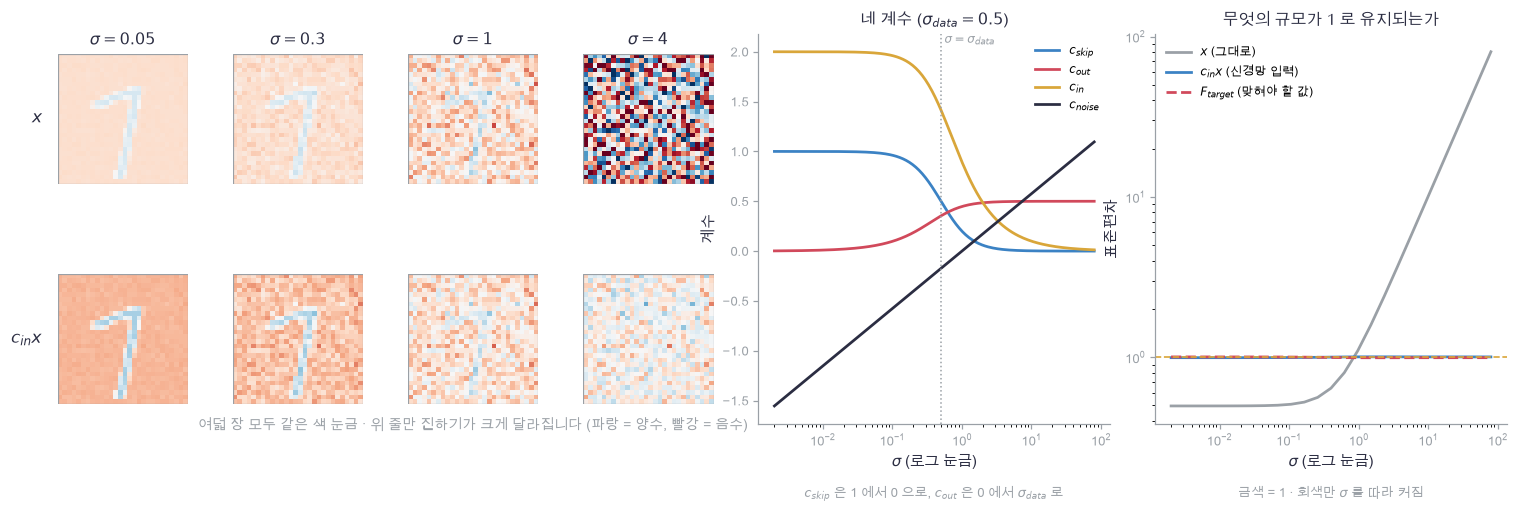

In [21]:
plot_preconditioning(band_sigmas, band_raw, band_scaled, band_vmax,
                     coef_sigmas, coef_curves, scale_sigmas, scale_rows, SIGMA_DATA)

🔍 **확인** · 위 두 줄이 이 절의 전부입니다. 위 줄(그대로)은 $\sigma=0.05$에서는 거의 흰 종이처럼 흐리고 $\sigma=4$에서는 색이 꽉 찹니다. **같은 색 눈금**으로 그렸기 때문이고, 신경망이 그대로 받으면 입력의 크기가 80배 넘게 오간다는 뜻입니다.
아래 줄($c_{in}$을 곱한 것)은 네 장 모두 비슷한 진하기입니다. 달라지는 것은 "7이 얼마나 보이는가"뿐입니다. $\sigma=0.05$에서는 7이 또렷하고 $\sigma=4$에서는 거의 잡음만 남습니다. **신경망이 실제로 보는 것은 아래 줄이고**, 규모 걱정 없이 "이 그림에 7이 얼마나 남아 있나"에만 집중할 수 있습니다.
가운데 계수 곡선에서 $c_{skip}$은 1에서 0으로, $c_{out}$은 0에서 $\sigma_{data}$로 갑니다. $c_{skip}$이 0.5가 되는 자리가 $\sigma=\sigma_{data}$입니다(점선). 두 곡선이 실제로 만나는 곳은 그보다 조금 오른쪽입니다. 작은 $\sigma$에서 $c_{skip}\approx1$·$c_{out}\approx0$이므로 $D\approx x$이고, 신경망의 출력은 거의 쓰이지 않습니다. 큰 $\sigma$에서는 반대로 $D\approx c_{out}F$라 신경망이 답을 다 만듭니다.
맨 오른쪽에서 회색($x$)만 $\sigma$를 따라 올라가고, 파랑($c_{in}x$)과 빨강($F_{target}$)은 금색 선 1에 붙어 있습니다. **네 계수가 한 일이 바로 이것입니다.**

아래 구현은 네 계수를 한 번에 돌려주는 함수 하나입니다.

In [22]:
# 쓰는 것: SIGMA_DATA (📎 규약 셀)
def precondition(sigma, sigma_data=SIGMA_DATA):
    """EDM 전처리 계수 네 개 (Karras 표 1): c_skip = σ_d²/(σ²+σ_d²), c_out = σσ_d/√(σ²+σ_d²),
    c_in = 1/√(σ²+σ_d²), c_noise = ln σ/4. sigma: 숫자 하나 또는 (N, 1) → 같은 모양 네 개."""
    assert np.all(np.asarray(sigma) > 0), "σ 는 0 보다 커야 합니다"
    total = sigma ** 2 + sigma_data ** 2                             # σ² + σ_data²: 잡음 섞인 입력의 분산
    c_skip = sigma_data ** 2 / total
    c_out = sigma * sigma_data / np.sqrt(total)
    return c_skip, c_out, 1 / np.sqrt(total), np.log(sigma) / 4

In [23]:
# 쓰는 것: SIGMA_DATA (📎 규약 셀, precondition 의 기본값) · coef_sigmas, coef_curves (2절 계수 셀)
hand_skip, hand_out, hand_in, hand_noise = precondition(1.0, 0.5)
np.testing.assert_allclose([hand_skip, hand_out, hand_in, hand_noise],   # 검산: 손계산 0.25/1.25, 0.5/√1.25, 1/√1.25, ln1/4
                           [0.2, 0.447214, 0.894427, 0.0], atol=1e-6)
np.testing.assert_allclose(hand_out ** 2, (1 - hand_skip) ** 2 * 0.25 + hand_skip ** 2 * 1.0)   # 검산: 조건 2 의 c_out² 식
all_skip, all_out, all_in, all_noise = precondition(coef_sigmas)
for name, made in zip(coef_curves, [all_skip, all_out, all_in, all_noise]):
    np.testing.assert_allclose(made, coef_curves[name])               # 검산: 위 그림의 네 곡선과 같음
candidates = np.linspace(0.0, 1.0, 100001)                            # (100001,): c_skip 후보를 촘촘히
needed = np.sqrt((1 - candidates) ** 2 * 0.25 + candidates ** 2 * 1.0)   # 후보마다 조건 2 가 요구하는 c_out
assert abs(candidates[needed.argmin()] - hand_skip) < 1e-4, "c_skip 은 c_out 을 가장 작게 만드는 값이어야 합니다"
print(f"손계산 (c_skip, c_out, c_in, c_noise) = ({hand_skip}, {hand_out:.6f}, {hand_in:.6f}, {hand_noise})")
print(f"c_out 을 최소로 만드는 c_skip: 격자 탐색 {candidates[needed.argmin()]:.5f} = 닫힌식 {hand_skip}")

손계산 (c_skip, c_out, c_in, c_noise) = (0.2, 0.447214, 0.894427, 0.0)
c_out 을 최소로 만드는 c_skip: 격자 탐색 0.20000 = 닫힌식 0.2


In [24]:
# 쓰는 것: mix2_sample (📎 혼합 셀) · mix2_sigma_data (📎 검산 셀) · precondition (2절)
variance_rng = np.random.default_rng(3504)
variance_x0 = mix2_sample(200000, variance_rng)                       # (200000, 2): 혼합에서 뽑은 깨끗한 점
variance_rows = []                                                    # σ 마다 (Var(c_in x), Var(F_target))
for sigma in [0.01, 0.1, 1.0, 10.0, 80.0]:
    noisy = variance_x0 + sigma * variance_rng.normal(size=variance_x0.shape)
    c_skip, c_out, c_in, _ = precondition(sigma, mix2_sigma_data)
    variance_rows.append((float(np.var(c_in * noisy)), float(np.var((variance_x0 - c_skip * noisy) / c_out))))
variance_rows = np.array(variance_rows)                               # (5, 2)
assert np.max(np.abs(variance_rows - 1.0)) < 0.02, "다섯 σ 모두에서 입력과 타깃의 분산이 1 과 0.02 안에서 같아야 합니다"
print("σ = 0.01, 0.1, 1, 10, 80 에서 Var(c_in x) =", variance_rows[:, 0].round(4))
print("                        Var(F_target) =", variance_rows[:, 1].round(4))

σ = 0.01, 0.1, 1, 10, 80 에서 Var(c_in x) = [0.9991 0.999  0.9992 1.0022 0.9985]
                        Var(F_target) = [0.9987 0.9972 1.0019 0.9984 0.9991]


🔍 **확인** · 손계산 네 값이 맞고, $c_{out}^2$이 조건 2의 식과 같습니다. $c_{skip}$이 정말 "$c_{out}$을 가장 작게 만드는 값"인지는 **닫힌식을 쓰지 않고** 후보 10만 개를 훑어 확인했습니다. 격자에서 찾은 최소점이 $0.2$로 닫힌식과 같습니다.
마지막 셀은 2차원 혼합에서 점 20만 개를 실제로 뽑아 $\mathrm{Var}(c_{in}x)$와 $\mathrm{Var}(F_{target})$를 잰 것입니다. $\sigma$가 $0.01$에서 $80$까지 8,000배 오가는데도 둘 다 1에서 $0.02$ 안입니다. 유도에 쓴 "$\mathrm{Var}(x_0)=\sigma_{data}^2$" 가정이 실제 표본에서도 맞는다는 뜻입니다.
여기서 $\sigma_{data}$로는 MNIST의 $0.5$가 아니라 **이 혼합의 표준편차 $1.62$**를 넣었습니다. $\sigma_{data}$는 논문이 정해 준 상수가 아니라 **데이터마다 재는 값**이기 때문입니다. 어긋난 값을 넣으면 어떻게 되는지는 완성 예제에서 봅니다.

### ✏️ 연습 2 · 입력의 규모를 1 로 맞추는 $c_{in}$

$\sigma$와 $\sigma_{data}$에서 $c_{in}(\sigma)=1/\sqrt{\sigma^2+\sigma_{data}^2}$ 한 줄을 채우세요. 왜 이 값인지는 "$x=x_0+\sigma\epsilon$의 분산이 $\sigma_{data}^2+\sigma^2$이고, 표준편차로 나누면 1이 된다" 한 문장입니다.

In [25]:

def exercise_c_in(sigma, sigma_data):
    """연습 2: 입력에 곱하는 계수 c_in. sigma: 숫자 하나 또는 배열, sigma_data: 숫자 → sigma 와 같은 모양."""
    assert np.all(np.asarray(sigma) > 0), "σ 는 0 보다 커야 합니다"
    assert sigma_data > 0, "σ_data 는 0 보다 커야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: c_in = 1/√(σ² + σ_data²)  (sigma 와 같은 모양)
    ### 힌트: 2절 조건 1 입니다. precondition 의 세 번째 반환값과 같습니다.
    raise NotImplementedError
    return c_in

In [26]:

def check_c_in(candidate):
    """2절 손계산(σ = 1, σ_data = 0.5 → 0.894427), 본문 곡선, 그리고 표본의 분산이 1 이 되는지로 검사합니다."""
    # 쓰는 것: coef_sigmas, coef_curves (2절 계수 셀) · SIGMA_DATA (📎 규약 셀) · mix2_sample, mix2_sigma_data (📎 셀)
    np.testing.assert_allclose(candidate(1.0, 0.5), 0.894427, atol=1e-6)   # 검산: 손계산 1/√1.25
    np.testing.assert_allclose(candidate(coef_sigmas, SIGMA_DATA), coef_curves["$c_{in}$"])   # 검산: 2절 그림의 c_in 곡선
    rng_check = np.random.default_rng(6002)
    x0_c = mix2_sample(100000, rng_check)
    for sigma in [0.2, 2.0]:
        noisy = x0_c + sigma * rng_check.normal(size=x0_c.shape)
        assert abs(float(np.var(candidate(sigma, mix2_sigma_data) * noisy)) - 1.0) < 0.03, \
            "c_in 을 곱한 입력의 분산이 1 과 0.03 안에서 같아야 합니다"
    print("c_in: 손계산·본문 곡선·표본 분산 1 과 일치합니다.")

run_check(check_c_in, exercise_c_in, hint="c_in = 1 / np.sqrt(sigma ** 2 + sigma_data ** 2)")

☐ exercise_c_in: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: c_in = 1 / np.sqrt(sigma ** 2 + sigma_data ** 2)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
c_in = 1 / np.sqrt(sigma ** 2 + sigma_data ** 2)
```

</details>

## 🔑 3. 손실 가중과 $\sigma$ 분포: 모든 $\sigma$ 에 같은 무게를 주기

**이 절에서 가져갈 것:** 손실을 $\lambda(\sigma)\|D(x;\sigma)-x_0\|^2$로 두고 $\lambda(\sigma)=1/c_{out}(\sigma)^2$를 고르면 손실이 정확히 $\|F-F_{target}\|^2$가 되어, $\sigma$와 상관없이 "규모 1짜리 회귀" 하나가 됩니다. 남은 자유는 **$\sigma$를 어떤 분포에서 뽑는가**이고, EDM은 $\ln\sigma\sim\mathcal N(P_{mean},P_{std}^2)$를 씁니다.

34번 5절에서 본 문제가 있습니다. 같은 예측을 $\epsilon$ 자로 재면 큰 $t$가 쉽고, $x_0$ 자로 재면 작은 $t$가 쉬웠습니다. 어느 자를 쓰느냐에 따라 "어려운 시각"이 뒤바뀌었고, 그래서 어느 $\sigma$에 학습을 집중할지가 **자 고르기에 숨어 있었습니다.**
EDM은 그 선택을 밖으로 꺼냅니다. 자는 $D$ 하나로 고정하고, "어느 $\sigma$에 얼마나 무게를 둘까"를 $\lambda(\sigma)$와 $p(\sigma)$ 두 개로 **따로 적습니다.**

> **용어**
>
> - **손실 가중 $\lambda(\sigma)$**: $\sigma$마다 손실에 곱하는 양수. 어느 $\sigma$의 오차를 더 심각하게 볼지 정합니다.
> - **학습용 $\sigma$ 분포 $p(\sigma)$**: 스텝마다 $\sigma$를 뽑는 분포. 가중치와 곱해져 "$\sigma$마다의 실질 무게"가 됩니다. 아무리 $\lambda$가 커도 그 $\sigma$를 뽑지 않으면 배우지 않습니다.
> - **유효 손실**: 전처리를 풀어 쓴 뒤 신경망이 실제로 최소화하는 양. 여기서는 $\|F-F_{target}\|^2$입니다.

$x_0$·$\epsilon$·$x$는 $(N,D)$, $\sigma$는 $(N,1)$입니다. 목적은

$$L(\theta)=\mathbb E_{\sigma\sim p}\;\mathbb E_{x_0}\;\mathbb E_{\epsilon}\Big[\lambda(\sigma)\,\big\|D(x_0+\sigma\epsilon;\sigma)-x_0\big\|^2\Big].$$

2절의 정의를 그대로 넣으면 $D-x_0=c_{out}\,(F-F_{target})$입니다($F_{target}=(x_0-c_{skip}x)/c_{out}$의 정의를 옮긴 것뿐입니다). 그러므로

$$\lambda(\sigma)\|D-x_0\|^2=\lambda(\sigma)\,c_{out}^2\,\|F-F_{target}\|^2
\;\xrightarrow{\;\lambda=1/c_{out}^2\;}\;\|F-F_{target}\|^2.$$

$F_{target}$의 분산은 2절에서 1로 맞춰 두었으므로, **$\sigma$가 무엇이든 신경망은 "분산 1짜리 값을 맞히는 같은 난이도의 회귀"를 풉니다.** 반대로 가중을 빼면 $\|D-x_0\|^2$는 작은 $\sigma$에서 0에 가깝고 큰 $\sigma$에서 데이터 분산만큼 커져, 실질적으로 큰 $\sigma$만 배우게 됩니다.

$\sigma$는 어디서 뽑을까요. 너무 작으면 배울 것이 없고($D\approx x$) 너무 크면 답이 데이터 평균 하나입니다. 가운데가 중요하므로 EDM은 로그 눈금에서 종 모양으로 뽑습니다.

$$\ln\sigma\sim\mathcal N(P_{mean},\,P_{std}^2),\qquad P_{mean}=-1.2,\quad P_{std}=1.2.$$

**손계산** $\sigma_{data}=0.5$, $\sigma=1$: 2절에서 $c_{out}=0.447214$였으므로 $\lambda(1)=1/0.2=5$입니다. 신경망이 한 좌표에서 1만큼 틀렸다면 $D$는 $0.447$만큼 틀리고, 가중한 손실은 $5\times0.447^2=1$로 되돌아옵니다. $\sigma=0.01$이면 $c_{out}=0.0099980$이라 $\lambda=(\sigma^2+\sigma_{data}^2)/(\sigma^2\sigma_{data}^2)=0.2501/0.000025\approx10{,}004$입니다. **작은 $\sigma$에서는 아주 작은 차이도 크게 셉니다.**

📎 $P_{mean}=-1.2$는 $\sigma_{data}=0.5$인 이미지를 기준으로 고른 값입니다. 데이터의 규모가 다르면 중심도 함께 옮겨야 합니다. 아래에서는 두 봉우리 혼합($\sigma_{data}=1.62$)에 $P_{mean}+\ln(\sigma_{data}/0.5)$를 씁니다.

아래 그림은 뽑히는 $\sigma$의 분포, 가중치 $\lambda(\sigma)$, 그리고 **정확한 $D$**(`mix2_denoiser`)로 잰 구간별 손실입니다. 학습한 모델이 아니라 정답 denoiser로 재므로, 보이는 차이는 전부 "자"의 차이입니다.

In [27]:
# 쓰는 것: P_MEAN, P_STD, SIGMA_DATA, SIGMA_MIN (📎 규약 셀) · mix2_sigma_data (📎 검산 셀)
mix2_p_mean = P_MEAN + float(np.log(mix2_sigma_data / SIGMA_DATA))   # 데이터 규모에 맞춰 옮긴 ln σ 의 중심
mix2_sigma_max = 10.0                                                # 두 봉우리 혼합에서 쓸 σ_max (데이터 규모의 6배쯤)
weight_rng = np.random.default_rng(3505)
weight_log_samples = mix2_p_mean + P_STD * weight_rng.normal(size=20000)   # (20000,): 뽑힌 ln σ
weight_sigmas = np.geomspace(SIGMA_MIN, mix2_sigma_max, 200)         # (200,): λ 를 그릴 σ 축
weight_c_out = weight_sigmas * mix2_sigma_data / np.sqrt(weight_sigmas ** 2 + mix2_sigma_data ** 2)   # (200,): c_out
weight_curve = 1 / weight_c_out ** 2                                 # (200,): λ(σ) = 1/c_out²
print("ln σ 의 중심:", round(mix2_p_mean, 3), "→ σ 의 중앙값", round(float(np.exp(mix2_p_mean)), 3))
print("손계산 λ(1) =", round(float(1 / (1.0 * 0.5 / np.sqrt(1.25)) ** 2), 4),
      "· λ(0.01) =", round(float(1 / (0.01 * 0.5 / np.sqrt(0.01 ** 2 + 0.25)) ** 2), 1), "(σ_data = 0.5)")

ln σ 의 중심: -0.023 → σ 의 중앙값 0.977
손계산 λ(1) = 5.0 · λ(0.01) = 10004.0 (σ_data = 0.5)


In [28]:
# 쓰는 것: mix2_sample, mix2_denoiser (📎 혼합 셀) · mix2_sigma_data (📎 검산 셀)
bin_sigmas = [0.1, 0.3, 1.0, 3.0, 10.0]                              # 구간을 대표하는 다섯 σ
bin_labels = [f"{sigma:g}" for sigma in bin_sigmas]
bin_rng = np.random.default_rng(3506)
bin_x0 = mix2_sample(4000, bin_rng)                                  # (4000, 2): 깨끗한 점
bin_raw, bin_weighted = [], []                                       # 가중 없는 손실과 λ 가중 손실
for sigma in bin_sigmas:
    noisy = bin_x0 + sigma * bin_rng.normal(size=bin_x0.shape)       # (4000, 2): x = x₀ + σ ε
    squared = np.sum((mix2_denoiser(noisy, sigma) - bin_x0) ** 2, axis=1)   # (4000,): ‖D* − x₀‖² (정확한 D)
    c_out = sigma * mix2_sigma_data / np.sqrt(sigma ** 2 + mix2_sigma_data ** 2)
    bin_raw.append(float(squared.mean()))
    bin_weighted.append(float(squared.mean() / c_out ** 2))
print("가중 없는 손실:", np.round(bin_raw, 4), "→ 최대/최소", round(max(bin_raw) / min(bin_raw), 1), "배")
print("λ 가중 손실:  ", np.round(bin_weighted, 4), "→ 최대/최소", round(max(bin_weighted) / min(bin_weighted), 2), "배")

가중 없는 손실: [0.0196 0.1564 0.9879 3.5183 5.0757] → 최대/최소 259.6 배
λ 가중 손실:   [1.9626 1.7969 1.3632 1.7275 1.979 ] → 최대/최소 1.45 배


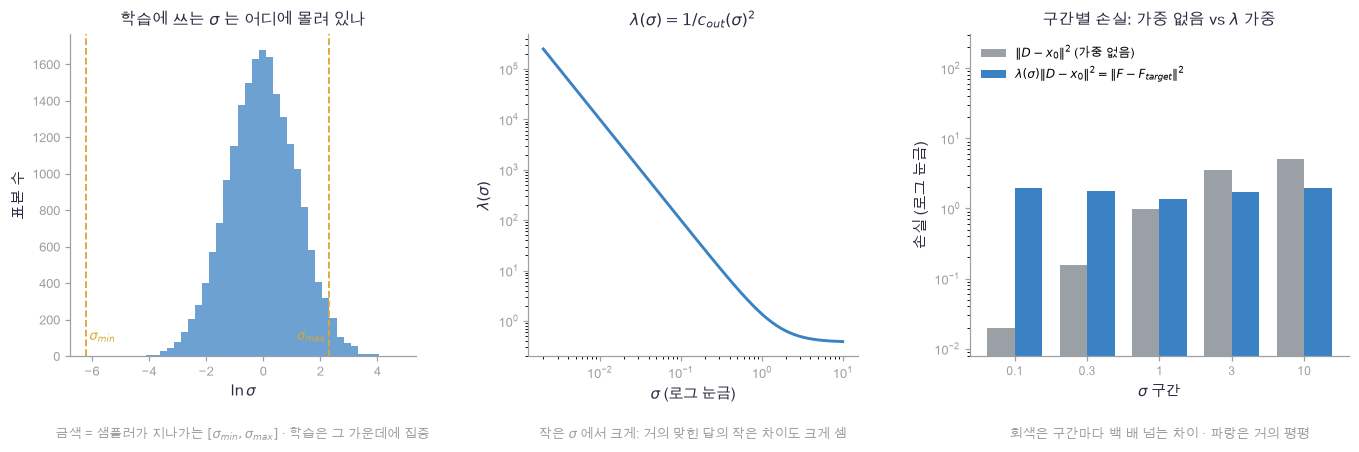

In [29]:
plot_loss_weighting(weight_log_samples, weight_sigmas, weight_curve, (SIGMA_MIN, mix2_sigma_max),
                    bin_labels, bin_raw, bin_weighted)

🔍 **확인** · 왼쪽에서 뽑히는 $\ln\sigma$는 종 모양이고, 금색 선으로 그린 샘플러의 양 끝($0.002$와 $10$) 가운데 왼쪽 끝($\sigma_{min}$)에서는 아주 멀고, 오른쪽은 $\sigma_{max}$를 조금 넘는 꼬리(약 2.6%)만 남습니다. 샘플러는 $\sigma=10$에서 출발하지만 거기서는 배울 것이 거의 없으므로(답이 데이터 평균 하나) 학습을 낭비하지 않습니다.
가운데 $\lambda(\sigma)$는 작은 $\sigma$에서 폭발합니다. $\sigma\to0$이면 $c_{out}\to0$이라 신경망 출력이 답에 거의 실리지 않으므로, 그만큼 크게 곱해야 "1만큼 틀린 것"이 손실 1이 됩니다.
오른쪽 막대가 이 절의 결론입니다. **같은 정확한 denoiser**를 가중 없이 재면(회색) 구간마다 260배 차이가 나서 큰 $\sigma$만 중요한 것처럼 보입니다. $\lambda$로 가중하면(파랑) 1.5배 안으로 들어옵니다. 어느 $\sigma$가 중요한지를 정하는 것은 이제 자가 아니라 우리가 고른 $p(\sigma)$뿐입니다.

아래 구현은 $\sigma$ 뽑기, 조건 입력 펼치기, 신경망 $F$의 forward·backward, 전처리로 감싼 $D$, 그리고 손실입니다.

> **코드**
>
> - `np.geomspace(1.0, 16.0, width // 2)`: 로그 눈금에서 고르게 나눈 진동수. 09번 4절의 sinusoidal 표와 같은 생각이고, 여기서는 정수 시각 대신 실수 $c_{noise}$를 펼칩니다.
> - `table[:, 0::2], table[:, 1::2] = np.sin(angles), np.cos(angles)`: 짝수 열에 sin, 홀수 열에 cos을 한 번에 넣습니다.
> - `c_noise[:, 0]`: `(N, 1)`을 `(N,)`으로 눕힙니다. 조건 입력은 표본마다 숫자 하나입니다.

In [30]:
# 쓰는 것: P_MEAN, P_STD (📎 규약 셀)
def sample_sigma(n, rng, p_mean=P_MEAN, p_std=P_STD):
    """학습용 σ 를 뽑습니다 (Karras 표 1): ln σ ~ N(p_mean, p_std²). n: 개수 → (n, 1) 양수."""
    assert p_std > 0, "ln σ 의 표준편차는 0 보다 커야 합니다"
    return np.exp(p_mean + p_std * rng.normal(size=(n, 1)))


def sigma_embedding(c_noise, width):
    """조건 입력 c_noise 를 여러 진동수의 sin·cos 로 펼칩니다 (09번 4절 sinusoidal 표의 실수판).
    c_noise: (N,), width: 짝수 E → (N, E)."""
    assert width % 2 == 0, "sin·cos 쌍을 두려면 폭이 짝수여야 합니다"
    frequencies = 2 * np.pi * np.geomspace(1.0, 16.0, width // 2)     # (E/2,): 느린 진동부터 빠른 진동까지
    angles = np.asarray(c_noise, dtype=float).reshape(-1, 1) * frequencies   # (N, E/2)
    table = np.empty((len(angles), width))
    table[:, 0::2], table[:, 1::2] = np.sin(angles), np.cos(angles)
    return table

In [31]:
def init_edm_net(data_dim, width, hidden, seed):
    """신경망 F 의 파라미터. 은닉 두 층(tanh): W1 (D+E, hidden), W2 (hidden, hidden), W3 (hidden, D).
    표준편차 1/√입력 초기화(03번 4절의 Glorot 초기화와 같은 생각으로 크기만 단순화)를 씁니다."""
    rng_init = np.random.default_rng(seed)
    return {"W1": rng_init.normal(size=(data_dim + width, hidden)) / np.sqrt(data_dim + width), "b1": np.zeros(hidden),
            "W2": rng_init.normal(size=(hidden, hidden)) / np.sqrt(hidden), "b2": np.zeros(hidden),
            "W3": rng_init.normal(size=(hidden, data_dim)) / np.sqrt(hidden), "b3": np.zeros(data_dim)}


def edm_forward(x_in, c_noise, p):
    """F 의 forward: U = [x_in, emb(c_noise)], A1 = tanh(U W1 + b1), A2 = tanh(A1 W2 + b2), F = A2 W3 + b3.
    x_in: (N, D) (이미 c_in 을 곱한 입력), c_noise: (N,) → (F: (N, D), cache: (U, A1, A2))."""
    # 쓰는 것: sigma_embedding (3절)
    width = p["W1"].shape[0] - x_in.shape[1]                          # 조건 표의 폭 = 입력 폭 − 데이터 차원
    U = np.concatenate([x_in, sigma_embedding(c_noise, width)], axis=1)   # (N, D+E)
    A1 = np.tanh(U @ p["W1"] + p["b1"])                               # (N, hidden)
    A2 = np.tanh(A1 @ p["W2"] + p["b2"])                              # (N, hidden)
    return A2 @ p["W3"] + p["b3"], (U, A1, A2)

In [32]:
def edm_backward(dF, cache, p):
    """backward: 03번 5절의 두 층 규칙을 세 층에. dZ = dA ⊙ (1 − A²) 로 tanh 를 지나고, 층마다 dW = 입력ᵀ dZ.
    dF: (N, D), cache: edm_forward 의 것 → grads: p 와 같은 키의 사전."""
    U, A1, A2 = cache
    dZ2 = (dF @ p["W3"].T) * (1 - A2 ** 2)                            # (N, hidden): 둘째 은닉층의 기울기
    dZ1 = (dZ2 @ p["W2"].T) * (1 - A1 ** 2)                           # (N, hidden): 첫째 은닉층의 기울기
    return {"W1": U.T @ dZ1, "b1": dZ1.sum(axis=0), "W2": A1.T @ dZ2, "b2": dZ2.sum(axis=0),
            "W3": A2.T @ dF, "b3": dF.sum(axis=0)}

In [33]:
def edm_denoise(x, sigma, p, sigma_data=SIGMA_DATA):
    """전처리로 감싼 최적 복원 D(x;σ) = c_skip x + c_out F(c_in x; c_noise) (2절).
    x: (N, D), sigma: 숫자 하나 또는 (N, 1) → (N, D)."""
    # 쓰는 것: SIGMA_DATA (📎 규약 셀) · precondition (2절) · edm_forward (3절)
    c_skip, c_out, c_in, c_noise = precondition(sigma, sigma_data)
    condition = np.broadcast_to(np.asarray(c_noise, dtype=float).reshape(-1), (len(x),))   # (N,): 표본마다 숫자 하나
    return c_skip * x + c_out * edm_forward(c_in * x, condition, p)[0]


def edm_loss(x0, sigma, eps, p, sigma_data=SIGMA_DATA):
    """EDM 손실 λ(σ)‖D − x₀‖² = ‖F − F_target‖², F_target = (x₀ − c_skip x)/c_out.
    x0, eps: (N, D), sigma: (N, 1) → (loss: 숫자, grads: p 와 같은 키의 사전)."""
    # 쓰는 것: precondition (2절) · edm_forward, edm_backward (3절)
    c_skip, c_out, c_in, c_noise = precondition(sigma, sigma_data)
    x = x0 + sigma * eps                                              # (N, D): x = x₀ + σ ε
    F, cache = edm_forward(c_in * x, c_noise[:, 0], p)                # (N, D): 신경망이 낸 값
    residual = F - (x0 - c_skip * x) / c_out                          # (N, D): F − F_target
    return float(np.mean(np.sum(residual ** 2, axis=1))), edm_backward(2 * residual / len(x0), cache, p)

In [34]:
def adam_step(p, grads, state, step, lr):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p 를 제자리에서 바꾸고 state 의 (m, v)를 갱신합니다."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                                # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                       # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [35]:
def train_edm(X0, steps, seed, sigma_data, p_mean, hidden=128, width=16, batch=256, lr=3e-3):
    """스텝마다 미니배치 x₀ 를 뽑고 σ 를 ln σ ~ N(p_mean, P_STD²) 에서 뽑아 F 를 맞히게 합니다 (01b번 4절의 루프).
    X0: (N, D) 깨끗한 데이터 → (p: 파라미터 사전, history: 스텝별 손실 (steps,))."""
    # 쓰는 것: init_edm_net, sample_sigma, edm_loss, adam_step (3절)
    p = init_edm_net(X0.shape[1], width, hidden, seed)
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}   # Adam 상태 (m, v)
    rng_train = np.random.default_rng(seed + 1)
    history = []
    for step in range(1, steps + 1):
        X_batch = X0[rng_train.choice(len(X0), batch, replace=False)]   # (batch, D): 겹치지 않게 뽑은 미니배치
        sigma = sample_sigma(batch, rng_train, p_mean)                 # (batch, 1): 스텝마다 새 σ
        loss, grads = edm_loss(X_batch, sigma, rng_train.normal(size=X_batch.shape), p, sigma_data)
        adam_step(p, grads, state, step, lr)
        history.append(loss)
    return p, np.array(history)

In [36]:
# 쓰는 것: mix2_sigma_data (📎 검산 셀) · init_edm_net, edm_loss (3절)
probe_p = init_edm_net(2, 8, 6, 3507)                                 # 작은 2차원 모델 (은닉 6, 조건 표 8)
probe_rng = np.random.default_rng(3508)
probe_x0 = probe_rng.normal(size=(5, 2))                              # (5, 2): 검사용 깨끗한 점
probe_sigma = np.exp(probe_rng.normal(size=(5, 1)))                   # (5, 1): 표본마다 다른 σ
probe_eps = probe_rng.normal(size=(5, 2))                             # (5, 2): 검사용 잡음
probe_loss, probe_grads = edm_loss(probe_x0, probe_sigma, probe_eps, probe_p, mix2_sigma_data)


def probe_scalar():
    """검사기용: 현재 파라미터의 EDM 손실 (같은 x₀·σ·ε)."""
    return edm_loss(probe_x0, probe_sigma, probe_eps, probe_p, mix2_sigma_data)[0]


probe_errors = {key: rel_error(probe_grads[key], numerical_gradient(probe_scalar, value)) for key, value in probe_p.items()}
assert max(probe_errors.values()) < 1e-6, "여섯 파라미터의 기울기가 중심차분과 1e−6 안에서 같아야 합니다"
print("EDM 손실 gradcheck 최대 상대오차:", f"{max(probe_errors.values()):.2e}", "· 손실", round(probe_loss, 4))

EDM 손실 gradcheck 최대 상대오차: 1.21e-09 · 손실 2.1924


In [37]:
# 쓰는 것: mix2_sample (📎 혼합 셀) · mix2_sigma_data (📎 검산 셀) · mix2_p_mean (3절 계산 셀) · precondition (2절) · edm_denoise, edm_loss, sample_sigma (3절) · probe_p, probe_rng (3절 검산 셀)
ident_x0 = mix2_sample(500, probe_rng)                                # (500, 2)
ident_sigma = sample_sigma(500, probe_rng, mix2_p_mean)               # (500, 1)
ident_eps = probe_rng.normal(size=ident_x0.shape)                     # (500, 2)
ident_c_out = precondition(ident_sigma, mix2_sigma_data)[1]           # (500, 1): c_out(σ)
ident_D = edm_denoise(ident_x0 + ident_sigma * ident_eps, ident_sigma, probe_p, mix2_sigma_data)   # (500, 2)
ident_weighted = float(np.mean(np.sum((ident_D - ident_x0) ** 2, axis=1) / ident_c_out[:, 0] ** 2))
np.testing.assert_allclose(edm_loss(ident_x0, ident_sigma, ident_eps, probe_p, mix2_sigma_data)[0], ident_weighted)   # 검산: ‖F − F_target‖² 로 잰 손실 = λ(σ)‖D − x₀‖² 의 평균 (D 는 edm_denoise 가 따로 만든 것)
print("‖F − F_target‖² 로 잰 손실과 λ(σ)‖D − x₀‖² 로 잰 손실이 같음:", round(ident_weighted, 6))

‖F − F_target‖² 로 잰 손실과 λ(σ)‖D − x₀‖² 로 잰 손실이 같음: 2.390512


🔍 **확인** · 두 검산이 통과했습니다. (1) 여섯 파라미터의 기울기가 중심차분과 $10^{-6}$ 안에서 같습니다. 전처리 계수가 곱해진 뒤에도 03번의 backward 규칙이 그대로 통한다는 뜻입니다. (2) `edm_loss`가 $\|F-F_{target}\|^2$로 계산한 값과, `edm_denoise`로 따로 만든 $D$에서 $\lambda(\sigma)\|D-x_0\|^2$로 계산한 값이 정확히 같습니다. 두 함수는 서로 다른 식을 쓰므로, 같다는 것은 $D-x_0=c_{out}(F-F_{target})$ 유도가 맞았다는 뜻입니다.

이제 2차원 혼합에서 실제로 학습합니다. 정답 $D$를 알고 있으므로, 학습이 끝난 뒤 **격자 위에서 정답과 직접 비교**할 수 있습니다. 학습용 작은 문제의 성능이며 실제 벤치마크로 읽지 마세요.

In [38]:
# 쓰는 것: mix2_sample, mix2_denoiser (📎 혼합 셀) · mix2_sigma_data (📎 검산 셀) · mix2_p_mean (3절 계산 셀) · train_edm, init_edm_net, edm_denoise (3절)
mixture_X0 = mix2_sample(4000, np.random.default_rng(3509))           # (4000, 2): 학습 데이터
mixture_p, mixture_history = train_edm(mixture_X0, 3000, 3510, mix2_sigma_data, mix2_p_mean)
mixture_p0 = init_edm_net(2, 16, 128, 3510)                           # 학습 전 파라미터 (학습과 같은 seed)
grid_xx, grid_yy = np.meshgrid(np.linspace(-4, 4, 25), np.linspace(-3, 4, 22))   # (22, 25) 둘: 비교할 격자
grid_points = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])     # (550, 2)
grid_before, grid_after = [], []                                      # σ 마다 정답 D 와의 RMSE
for sigma in [0.1, 0.5, 2.0]:
    exact = mix2_denoiser(grid_points, sigma)                         # (550, 2): 정답
    for params, bucket in [(mixture_p0, grid_before), (mixture_p, grid_after)]:
        learned = edm_denoise(grid_points, sigma, params, mix2_sigma_data)
        bucket.append(float(np.sqrt(np.mean(np.sum((learned - exact) ** 2, axis=1)))))
assert np.all(np.array(grid_after) < np.array(grid_before)), "세 σ 모두에서 학습 뒤 격자 오차가 학습 전보다 작아야 합니다"
assert np.mean(grid_after) < np.mean(grid_before) / 3, "평균 격자 오차가 학습 전의 1/3 아래여야 합니다"
assert max(grid_after) < 0.6, "학습한 D 는 격자 위에서 정답과 RMSE 0.6 안에 있어야 합니다"
mixture_smooth = np.convolve(mixture_history, np.ones(100) / 100, mode="valid")   # (2901,): 100 스텝 이동평균
print(f"손실 {mixture_history[:100].mean():.4f} → {mixture_history[-200:].mean():.4f}")
print("σ = 0.1, 0.5, 2.0 에서 격자 RMSE: 학습 전", np.round(grid_before, 3), "→ 학습 후", np.round(grid_after, 3))

손실 1.8355 → 1.6604
σ = 0.1, 0.5, 2.0 에서 격자 RMSE: 학습 전 [0.055 0.528 0.955] → 학습 후 [0.025 0.22  0.131]


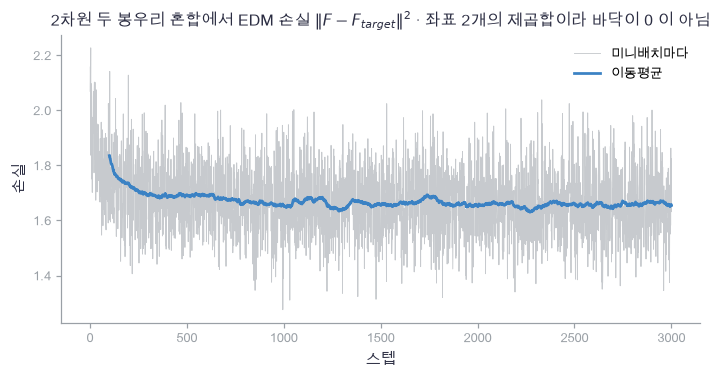

In [39]:
plot_training_loss(np.arange(1, len(mixture_history) + 1), mixture_history,
                   np.arange(100, len(mixture_history) + 1), mixture_smooth,
                   "2차원 두 봉우리 혼합에서 EDM 손실 $\\|F - F_{target}\\|^2$ · 좌표 2개의 제곱합이라 바닥이 0 이 아님")

🔍 **확인** · 손실이 내려가다 평평해집니다. 0으로 가지 않는 것이 정상입니다. 같은 $x$에 여러 $x_0$가 섞여 있으므로 최선을 다해도 $\mathbb E\|F^*-F_{target}\|^2$가 남습니다(34번 4절과 같은 이야기). 그래서 학습을 평가할 때는 손실값이 아니라 **정답 $D$와의 거리**를 봅니다.
격자 위에서 재면 세 $\sigma$ 모두 학습 뒤 오차가 줄고 평균은 3분의 1 아래입니다. 눈여겨볼 것은 **학습 전 모델도 작은 $\sigma$에서는 이미 꽤 맞는다**는 점입니다. $\sigma=0.1$에서는 $c_{skip}\approx1$·$c_{out}\approx0.1$이라 $D\approx x$가 답의 대부분이고, 신경망이 아무 값이나 내도 크게 틀리지 않습니다. 2절의 전처리가 "쉬운 부분을 신경망에게 맡기지 않는다"는 것이 이렇게 보입니다.
남은 오차는 대부분 데이터가 거의 없는 격자 구석에서 나옵니다. 그 자리는 학습에서 거의 뽑히지 않으므로 신경망이 배울 기회가 없었습니다. **모델의 오차는 "데이터가 있는 곳"에서만 작습니다.** 4절에서 이 사실이 샘플러의 정확도에 어떻게 나타나는지 봅니다.

### ✏️ 연습 3 · $\sigma$ 마다의 손실 가중 $\lambda(\sigma)$

$c_{out}$에서 $\lambda(\sigma)=1/c_{out}(\sigma)^2$ 한 줄을 채우세요. 끝의 연습 C가 "$\sigma$를 어디서 뽑나"를 묻는다면, 이 연습은 "뽑은 $\sigma$에 얼마나 무게를 주나"를 봅니다.

In [40]:

def exercise_loss_weight(c_out):
    """연습 3: 손실 가중 λ(σ) = 1/c_out². c_out: 숫자 하나 또는 배열 → 같은 모양."""
    assert np.all(np.asarray(c_out) > 0), "c_out 은 0 보다 커야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: weight = 1/c_out²  (c_out 과 같은 모양)
    ### 힌트: 3절의 λ = 1/c_out² 한 줄입니다.
    raise NotImplementedError
    return weight

In [41]:

def check_loss_weight(candidate):
    """3절 손계산(σ_data = 0.5, σ = 1 → 5)과 본문 곡선, 그리고 유효 손실이 규모 1 이 되는지로 검사합니다."""
    # 쓰는 것: weight_c_out, weight_curve (3절 계산 셀) · precondition (2절)
    np.testing.assert_allclose(candidate(precondition(1.0, 0.5)[1]), 5.0, atol=1e-9)   # 검산: 손계산 1/0.2 = 5
    np.testing.assert_allclose(candidate(weight_c_out), weight_curve)   # 검산: 3절 그림의 λ 곡선
    c_out_small = precondition(0.01, 0.5)[1]
    assert candidate(c_out_small) > 10000.0, "작은 σ 에서는 가중치가 1 만을 넘어야 합니다"
    np.testing.assert_allclose(candidate(0.4) * (0.4 * 2.5) ** 2, 2.5 ** 2)   # 검산: λ c_out² = 1 이므로 λ(0.4)(0.4·2.5)² = 2.5²
    print("λ(σ): 손계산 5·본문 곡선과 일치합니다.")

run_check(check_loss_weight, exercise_loss_weight, hint="weight = 1 / c_out ** 2")

☐ exercise_loss_weight: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: weight = 1 / c_out ** 2


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
weight = 1 / c_out ** 2
```

</details>

## 🔑 4. 샘플링은 미분방정식 풀기: 시간 격자와 Euler·Heun

**이 절에서 가져갈 것:** $\sigma$를 큰 값에서 0까지 줄여 가며 $\dfrac{dx}{d\sigma}=\dfrac{x-D(x;\sigma)}{\sigma}$를 적분하면 샘플이 나옵니다. 걸음을 어디에 몰아 둘지는 $\sigma_i=\Big(\sigma_{max}^{1/\rho}+\frac{i}{N-1}\big(\sigma_{min}^{1/\rho}-\sigma_{max}^{1/\rho}\big)\Big)^\rho$가 정하고, 도착 예정점에서 기울기를 한 번 더 재는 Heun은 같은 $D$ 호출 수에서 훨씬 정확합니다.

35번의 DDIM은 $x_{t-1}=\sqrt{\bar\alpha_{t-1}}\hat x_0+\sqrt{1-\bar\alpha_{t-1}}\hat\epsilon$ 한 줄이었고, 시간열을 건너뛰어도 그럴듯한 그림이 나왔습니다. 왜 건너뛸 수 있었을까요?
$\sigma$ 좌표에서 보면 그 한 줄은 **미분방정식의 Euler 걸음**입니다. 그러면 "걸음 수를 줄인다"는 말은 "적분을 성기게 한다"는 말이 되고, 수치해석이 200년 동안 쌓아 온 답(더 좋은 적분기, 더 좋은 격자)을 그대로 가져올 수 있습니다.

> **용어**
>
> - **확률 흐름 ODE(probability flow ODE)**: 잡음을 더하는 과정과 **같은 시각별 분포** $q_\sigma$를 가지면서 무작위성이 전혀 없는 미분방정식. 출발점 $x$를 정하면 도착점이 하나로 정해집니다.
> - **적분기(solver)**: 미분방정식을 걸음으로 나누어 푸는 방법. **Euler 걸음**은 기울기를 한 번 재서 직선으로 갑니다(01번 2절의 접선을 따라가는 것과 같습니다).
> - **Heun 걸음**: 도착 예정점에서 기울기를 한 번 더 재고, 두 기울기의 **평균**으로 다시 가는 방법. 사다리꼴 규칙이라고도 합니다.
> - **차수(order)**: 걸음 폭을 절반으로 줄일 때 오차가 몇 배로 줄어드는가. 1차는 절반, 2차는 4분의 1입니다.

$x$는 $(N,D)$, $\sigma$는 걸음마다 숫자 하나입니다. 1절의 Tweedie를 쓰면 기울기는 $D$ 하나로 적힙니다.

$$\frac{dx}{d\sigma}=-\sigma\,\nabla_x\log q_\sigma(x)=-\sigma\cdot\frac{D(x;\sigma)-x}{\sigma^2}=\boxed{\;\frac{x-D(x;\sigma)}{\sigma}\;}$$

$x-D$는 "데이터에서 멀어지는 방향"이고, 우리는 $\sigma$를 **줄이며** 가므로 $d\sigma<0$입니다. 음수를 곱하니 실제로는 데이터 쪽으로 갑니다. 한 걸음은

$$d_i=\frac{x_i-D(x_i;\sigma_i)}{\sigma_i},\qquad x_{i+1}=x_i+(\sigma_{i+1}-\sigma_i)\,d_i \quad\text{(Euler)}$$

이고, Heun은 여기서 한 번 더 고칩니다. $\sigma_{i+1}=0$이면 $D$를 다시 부를 수 없으므로 마지막 걸음은 Euler 그대로 둡니다.

$$d_i'=\frac{x_{i+1}-D(x_{i+1};\sigma_{i+1})}{\sigma_{i+1}},\qquad
x_{i+1}\leftarrow x_i+(\sigma_{i+1}-\sigma_i)\cdot\frac{d_i+d_i'}{2}\quad\text{(Heun)}.$$

걸음을 어디에 둘지는 따로 정합니다. $\rho=1$이면 $\sigma$ 축에서 균등하고, $\rho$가 커질수록 **작은 $\sigma$ 쪽에 걸음이 몰립니다.** 작은 $\sigma$에서 $D$가 빠르게 변하기 때문입니다(1절 오른쪽 그림의 계단).

$$\sigma_i=\Big(\sigma_{max}^{1/\rho}+\tfrac{i}{N-1}\big(\sigma_{min}^{1/\rho}-\sigma_{max}^{1/\rho}\big)\Big)^{\rho},\quad i=0,\dots,N-1,\qquad \sigma_N=0.$$

**손계산 (1)** $N=3$, $\sigma_{max}=4$, $\sigma_{min}=1$: $\rho=1$이면 $\sigma=(4,\,2.5,\,1,\,0)$으로 $\sigma$ 축에서 균등합니다. $\rho=2$면 $\sqrt\sigma$가 $(2,\,1.5,\,1)$로 균등하므로 $\sigma=(4,\,2.25,\,1,\,0)$이고, 작은 쪽 간격 $1.25$가 큰 쪽 간격 $1.75$보다 좁습니다.

**손계산 (2)** 데이터가 원점의 점 하나뿐이면 $D(x;\sigma)=0$이므로 $dx/d\sigma=x/\sigma$이고 정확한 해는 $x(\sigma)=x_0\,\sigma/\sigma_0$입니다. Euler 한 걸음은 $x_1=x_0+(\sigma_1-\sigma_0)\frac{x_0}{\sigma_0}=x_0\frac{\sigma_1}{\sigma_0}$으로 **정확히 같습니다.** $x_0=8$, $\sigma_0=4$, $\sigma_1=2$면 $x_1=4$입니다. 오차가 생기는 것은 $D$가 $x$에 따라 휘기 때문입니다.

아래는 $\rho$별 격자와, 2차원 혼합에서 같은 출발점 네 개를 8걸음 Euler·8걸음 Heun·256걸음 기준 해로 푼 궤적입니다. 정확한 $D$(`mix2_denoiser`)를 쓰므로 여기 보이는 차이는 **전부 적분기의 오차**입니다.

> **코드** · `np.stack(trace)`: `(4, 2)` 배열 여러 개를 새 축으로 쌓아 `(걸음+1, 4, 2)`로 만듭니다. 첫 축이 시간, 둘째 축이 궤적 번호입니다.

In [42]:
# 쓰는 것: SIGMA_MIN, RHO (📎 규약 셀) · mix2_sigma_max (3절 계산 셀)
rho_grids = {}                                                        # ρ → (11,) σ 격자 (마지막은 0)
for rho in [1.0, 3.0, RHO]:
    ramp = np.arange(10) / 9                                          # (10,): 0 … 1
    grid = (mix2_sigma_max ** (1 / rho) + ramp * (SIGMA_MIN ** (1 / rho) - mix2_sigma_max ** (1 / rho))) ** rho
    rho_grids[rho] = np.concatenate([grid, [0.0]])                    # 마지막 걸음은 σ = 0
print("ρ = 1 격자:", rho_grids[1.0].round(3))
print("ρ = 7 격자:", rho_grids[RHO].round(3))
print("손계산 (N = 3, σ_max = 4, σ_min = 1): ρ = 1 → [4, 2.5, 1, 0] · ρ = 2 → [4, 2.25, 1, 0]")

ρ = 1 격자: [10.     8.889  7.778  6.667  5.556  4.446  3.335  2.224  1.113  0.002
  0.   ]
ρ = 7 격자: [10.     5.655  3.041  1.539  0.724  0.311  0.119  0.039  0.01   0.002
  0.   ]
손계산 (N = 3, σ_max = 4, σ_min = 1): ρ = 1 → [4, 2.5, 1, 0] · ρ = 2 → [4, 2.25, 1, 0]


In [43]:
# 쓰는 것: SIGMA_MIN, RHO (📎 규약 셀) · mix2_sigma_max (3절 계산 셀) · mix2_denoiser (📎 혼합 셀)
path_start = mix2_sigma_max * np.random.default_rng(3511).normal(size=(4, 2))   # (4, 2): σ_max 에서 뽑은 출발점
path_grids = {}                                                       # 이름 → σ 격자
for name, steps in [("기준 해 (Heun 256걸음)", 256), ("Euler 8걸음", 8), ("Heun 8걸음", 8)]:
    ramp = np.arange(steps) / (steps - 1)
    grid = (mix2_sigma_max ** (1 / RHO) + ramp * (SIGMA_MIN ** (1 / RHO) - mix2_sigma_max ** (1 / RHO))) ** RHO
    path_grids[name] = np.concatenate([grid, [0.0]])
path_traces = {}                                                      # 이름 → (걸음+1, 4, 2) 궤적
for name, sigmas in path_grids.items():
    x, trace = path_start.copy(), [path_start.copy()]
    for i in range(len(sigmas) - 1):
        slope = (x - mix2_denoiser(x, sigmas[i])) / sigmas[i]          # d_i = (x − D)/σ
        x_next = x + (sigmas[i + 1] - sigmas[i]) * slope               # Euler 걸음
        if name.startswith("Heun") or name.startswith("기준"):
            if sigmas[i + 1] > 0:                                      # σ = 0 에서는 D 를 다시 부를 수 없음
                end_slope = (x_next - mix2_denoiser(x_next, sigmas[i + 1])) / sigmas[i + 1]
                x_next = x + (sigmas[i + 1] - sigmas[i]) * 0.5 * (slope + end_slope)
        x = x_next
        trace.append(x.copy())
    path_traces[name] = np.stack(trace)
print("도착점 (Euler 8걸음):\n", path_traces["Euler 8걸음"][-1].round(3))
print("도착점 (Heun 8걸음):\n", path_traces["Heun 8걸음"][-1].round(3))
print("도착점 (기준 해):\n", path_traces["기준 해 (Heun 256걸음)"][-1].round(3))

도착점 (Euler 8걸음):
 [[ 1.437  2.549]
 [ 2.301  0.547]
 [-0.68   0.623]
 [ 0.994  1.861]]
도착점 (Heun 8걸음):
 [[ 1.517  3.349]
 [ 2.679  0.397]
 [-1.302  0.544]
 [ 1.169  2.433]]
도착점 (기준 해):
 [[ 1.48   3.051]
 [ 2.524  0.449]
 [-1.159  0.54 ]
 [ 1.12   2.227]]


In [44]:
# 쓰는 것: mix2_logpdf (📎 혼합 셀)
contour_xx, contour_yy = np.meshgrid(np.linspace(-5, 5, 121), np.linspace(-3.5, 4.5, 97))   # (97, 121) 둘
contour_pdf = np.exp(mix2_logpdf(np.column_stack([contour_xx.ravel(), contour_yy.ravel()]))).reshape(contour_xx.shape)
print("등고선 격자", contour_pdf.shape, "· 최대 밀도", round(float(contour_pdf.max()), 4))

등고선 격자 (97, 121) · 최대 밀도 0.1715


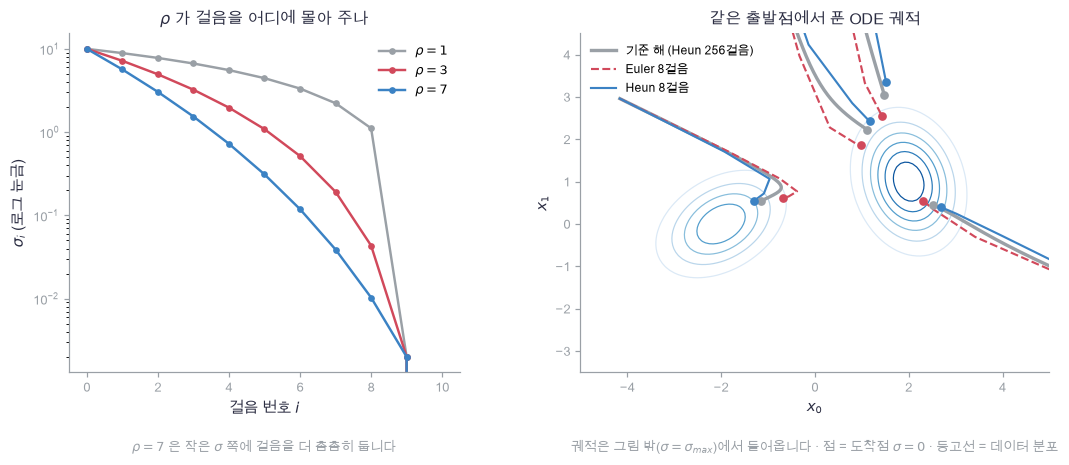

In [45]:
plot_ode_paths(rho_grids, (contour_xx, contour_yy, contour_pdf), path_traces)

🔍 **확인** · 왼쪽에서 $\rho=1$(회색)은 $\sigma$ 축에서 균등하므로 로그 눈금에서는 아래쪽이 확 벌어집니다. 마지막 한 걸음이 $\sigma$를 $1.11$에서 $0.002$까지 한 번에 건너뜁니다(세 자리 가까이 한 번에). $\rho=7$(파랑)은 작은 $\sigma$ 쪽에 걸음을 몰아 두어 로그 눈금에서 훨씬 고릅니다.
오른쪽 궤적에서 네 점 모두 바깥쪽 먼 곳에서 출발해 데이터가 있는 쪽으로 빨려 들어옵니다. 두 점은 등고선 안으로, 나머지 두 점은 오른쪽 봉우리 위쪽 꼬리에 내려앉습니다(샘플이므로 꼬리에도 떨어집니다). **무작위성은 한 번도 쓰지 않았습니다.** 출발점이 정해지면 도착점도 정해집니다. 8걸음 Euler(빨강 점선)와 8걸음 Heun(파랑)은 같은 출발점에서 갈라지고, Heun 쪽이 기준 해(회색 굵은 선)에 훨씬 가깝습니다.
$\sigma$가 큰 초반에는 세 궤적이 거의 겹칩니다. 그때는 $D$가 거의 상수(데이터 평균)라 손계산 (2)처럼 직선 운동에 가깝기 때문입니다. 갈라지는 것은 등고선 근처, 즉 $D$가 크게 휘는 곳입니다.

아래 구현은 격자와 두 적분기입니다. 위 계산 셀의 반복문을 함수로 옮긴 것뿐이고, 검산에서 같은 값을 내는지 확인합니다.

In [46]:
# 쓰는 것: RHO, SIGMA_MIN, SIGMA_MAX (📎 규약 셀)
def sigma_steps(N, rho=RHO, sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX):
    """EDM 시간 격자 (Karras 식 5): σ_i = (σ_max^(1/ρ) + i/(N−1)(σ_min^(1/ρ) − σ_max^(1/ρ)))^ρ, 마지막에 σ_N = 0.
    N: 걸음 수 (2 이상) → (N+1,) 내림차순 배열."""
    assert N >= 2, "걸음 수는 2 이상이어야 합니다"
    assert sigma_max > sigma_min > 0, "σ_max 는 σ_min 보다 크고 둘 다 양수여야 합니다"
    ramp = np.arange(N) / (N - 1)                                     # (N,): 0 … 1
    grid = (sigma_max ** (1 / rho) + ramp * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    return np.concatenate([grid, [0.0]])

In [47]:
def euler_sample(x, sigmas, denoiser):
    """확률 흐름 ODE 를 Euler 로 적분: x ← x + (σ_{i+1} − σ_i)(x − D(x;σ_i))/σ_i.
    x: (N, D) 출발점, sigmas: (N_step+1,), denoiser: (x, σ) → D → (N, D) 도착점."""
    for i in range(len(sigmas) - 1):
        x = x + (sigmas[i + 1] - sigmas[i]) * (x - denoiser(x, sigmas[i])) / sigmas[i]
    return x


def heun_sample(x, sigmas, denoiser):
    """같은 ODE 를 Heun 으로: Euler 로 도착 예정점을 구한 뒤 그곳의 기울기와 평균 내어 다시 갑니다 (Karras 알고리즘 1).
    x: (N, D), sigmas: (N_step+1,), denoiser: (x, σ) → D → (N, D)."""
    for i in range(len(sigmas) - 1):
        slope = (x - denoiser(x, sigmas[i])) / sigmas[i]              # d_i
        x_next = x + (sigmas[i + 1] - sigmas[i]) * slope              # Euler 로 본 도착 예정점
        if sigmas[i + 1] > 0:                                         # 마지막 걸음(σ = 0)은 보정하지 않음
            end_slope = (x_next - denoiser(x_next, sigmas[i + 1])) / sigmas[i + 1]   # d'_i
            x_next = x + (sigmas[i + 1] - sigmas[i]) * 0.5 * (slope + end_slope)
        x = x_next
    return x

In [48]:
# 쓰는 것: mix2_denoiser (📎 혼합 셀) · SIGMA_MIN (📎 규약 셀) · rho_grids, path_start, path_grids, path_traces (4절 계산 셀) · mix2_sigma_max (3절)
np.testing.assert_allclose(sigma_steps(3, 1.0, 1.0, 4.0), [4.0, 2.5, 1.0, 0.0])    # 검산: 손계산 ρ = 1 균등 격자
np.testing.assert_allclose(sigma_steps(3, 2.0, 1.0, 4.0), [4.0, 2.25, 1.0, 0.0])   # 검산: 손계산 ρ = 2
for rho, grid in rho_grids.items():
    np.testing.assert_allclose(sigma_steps(10, rho, SIGMA_MIN, mix2_sigma_max), grid)   # 검산: 위 그림의 세 격자
np.testing.assert_allclose(euler_sample(path_start.copy(), path_grids["Euler 8걸음"], mix2_denoiser),   # 검산: 위 그림의 Euler 도착점
                           path_traces["Euler 8걸음"][-1])
np.testing.assert_allclose(heun_sample(path_start.copy(), path_grids["Heun 8걸음"], mix2_denoiser),   # 검산: 위 그림의 Heun 도착점
                           path_traces["Heun 8걸음"][-1])
print("격자와 두 적분기가 손계산·위 그림과 일치합니다.")

격자와 두 적분기가 손계산·위 그림과 일치합니다.


In [49]:
def point_denoiser(x, sigma):
    """데이터가 원점의 점 하나뿐일 때의 최적 복원 D(x;σ) = 0. 손계산 (2)를 확인하려고 둡니다. x: (N, D) → (N, D)."""
    return np.zeros_like(x)

In [50]:
# 쓰는 것: euler_sample (4절) · point_denoiser (4절)
point_grid = np.array([4.0, 2.0, 1.0, 0.5])                           # σ 를 절반씩 줄이는 격자 (0 으로 끝나지 않음)
point_start = np.array([[8.0, -4.0]])                                 # (1, 2): σ = 4 에서의 출발점
point_end = euler_sample(point_start.copy(), point_grid, point_denoiser)
np.testing.assert_allclose(point_end, point_start * point_grid[-1] / point_grid[0])   # 검산: 정확한 해 x₀ σ/σ₀
np.testing.assert_allclose(euler_sample(point_start.copy(), np.array([4.0, 2.0]), point_denoiser), [[4.0, -2.0]])   # 검산: 손계산 (2) 한 걸음 x₁ = 8 × 2/4 = 4
print("데이터가 점 하나면 Euler 가 정확합니다:", point_end[0], "= 8, −4 의", point_grid[-1] / point_grid[0], "배")

데이터가 점 하나면 Euler 가 정확합니다: [ 1.  -0.5] = 8, −4 의 0.125 배


🔍 **확인** · 손계산 격자 두 개, 위 그림의 세 격자와 두 도착점, 그리고 "데이터가 점 하나면 Euler가 정확하다"는 손계산 (2)가 모두 맞습니다. 마지막 검산이 중요한 이유는 **적분기의 오차가 어디서 오는지**를 분리해 주기 때문입니다. $D$가 $x$에 대해 직선이면 Euler도 정확하고, 오차는 오로지 $D$가 휘는 만큼만 생깁니다.

이제 걸음 수를 늘려 가며 오차가 어떻게 줄어드는지 잽니다. 기준은 같은 출발점에서 **정확한 $D$**로 256걸음 넘게 푼 해이고, 세 가지를 비교합니다: 정확한 $D$ + Euler, 정확한 $D$ + Heun, 그리고 **학습한 $D$** + Heun입니다. 마지막이 이 실험의 핵심입니다.

In [51]:
# 쓰는 것: mix2_sigma_data (📎 검산 셀) · mixture_p (3절 학습 셀) · edm_denoise (3절) · mix2_denoiser (📎 혼합 셀) · sigma_steps, heun_sample (4절) · mix2_sigma_max (3절)
def learned_denoiser(x, sigma):
    """3절에서 학습한 모델의 D(x;σ). 샘플러에 넘길 수 있게 (x, σ) 두 인자만 받습니다. x: (N, 2) → (N, 2)."""
    return edm_denoise(x, sigma, mixture_p, mix2_sigma_data)


converge_start = mix2_sigma_max * np.random.default_rng(3512).normal(size=(256, 2))   # (256, 2): 공통 출발점
converge_reference = heun_sample(converge_start.copy(), sigma_steps(512, sigma_max=mix2_sigma_max), mix2_denoiser)
print("기준 해 준비:", converge_reference.shape, "· 평균", converge_reference.mean(axis=0).round(3))

기준 해 준비: (256, 2) · 평균 [0.313 0.47 ]


In [52]:
# 쓰는 것: converge_start, converge_reference, learned_denoiser (4절 기준 셀) · sigma_steps, euler_sample, heun_sample (4절) · mix2_denoiser (📎 혼합 셀) · mix2_sigma_max (3절)
converge_N = [5, 10, 20, 40, 80]
converge_errors = {"Euler (정확한 $D$)": [], "Heun (정확한 $D$)": [], "Heun (학습한 $D$)": []}
for N in converge_N:
    grid = sigma_steps(N, sigma_max=mix2_sigma_max)
    for name, final in [("Euler (정확한 $D$)", euler_sample(converge_start.copy(), grid, mix2_denoiser)),
                        ("Heun (정확한 $D$)", heun_sample(converge_start.copy(), grid, mix2_denoiser)),
                        ("Heun (학습한 $D$)", heun_sample(converge_start.copy(), grid, learned_denoiser))]:
        converge_errors[name].append(float(np.sqrt(np.mean(np.sum((final - converge_reference) ** 2, axis=1)))))
converge_slopes = {name: float(np.polyfit(np.log(converge_N[1:]), np.log(values[1:]), 1)[0])
                   for name, values in converge_errors.items()}      # N ≥ 10 에서 맞춘 로그-로그 기울기
for name, values in converge_errors.items():
    print(f"{name:18s}", np.array(values).round(5), f"· 기울기 {converge_slopes[name]:+.2f}")

Euler (정확한 $D$)    [0.6251 0.2903 0.1421 0.0704 0.035 ] · 기울기 -1.02
Heun (정확한 $D$)     [0.7041 0.1074 0.0212 0.0047 0.0011] · 기울기 -2.20
Heun (학습한 $D$)     [0.8697 0.2612 0.3076 0.1912 0.1982] · 기울기 -0.19


In [53]:
# 쓰는 것: converge_errors, converge_slopes (4절 실험 셀)
assert -1.2 < converge_slopes["Euler (정확한 $D$)"] < -0.85, "Euler 는 1차 적분기이므로 기울기가 −1 근처여야 합니다"
assert -2.6 < converge_slopes["Heun (정확한 $D$)"] < -1.8, "Heun 은 2차 적분기이므로 기울기가 −2 근처여야 합니다"
learned_errors = converge_errors["Heun (학습한 $D$)"]
assert learned_errors[-1] > 20 * converge_errors["Heun (정확한 $D$)"][-1], "학습한 D 의 오차는 적분기 오차보다 훨씬 큰 바닥에서 멈춰야 합니다"
assert learned_errors[-1] > 0.4 * learned_errors[2], "걸음을 4배로 늘려도 학습한 D 의 오차는 거의 줄지 않아야 합니다"
call_labels = ["Euler 20", "Heun 10", "Euler 40", "Heun 20"]
call_counts = [20, 19, 40, 39]                                        # Heun 은 걸음마다 D 를 두 번 (마지막 걸음은 한 번)
call_errors = [converge_errors["Euler (정확한 $D$)"][2], converge_errors["Heun (정확한 $D$)"][1],
               converge_errors["Euler (정확한 $D$)"][3], converge_errors["Heun (정확한 $D$)"][2]]
print("같은 비용 비교:", [f"{label} → {err:.4f}" for label, err in zip(call_labels, call_errors)])

같은 비용 비교: ['Euler 20 → 0.1422', 'Heun 10 → 0.1074', 'Euler 40 → 0.0704', 'Heun 20 → 0.0212']


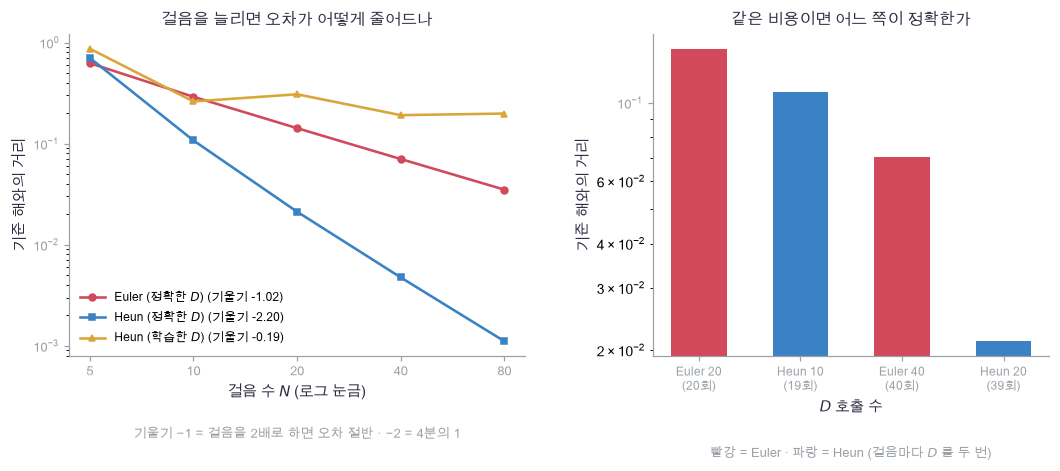

In [54]:
plot_solver_error(converge_N, converge_errors, converge_slopes, call_labels, call_counts, call_errors)

🔍 **확인** · 로그-로그에서 빨강(Euler)의 기울기는 $-1$ 근처, 파랑(Heun)은 $-2$ 근처입니다. 걸음을 2배로 늘리면 Euler는 오차가 절반, Heun은 4분의 1이 됩니다. **이것이 "1차"와 "2차"의 뜻입니다.**
오른쪽 막대는 같은 비용으로 비교한 것입니다. Heun은 걸음마다 $D$를 두 번 부르므로 10걸음이면 19번입니다. Euler 20번과 Heun 19번은 비용이 같은데 Heun이 더 정확하고, Euler 40번과 Heun 39번에서는 차이가 세 배 넘게 벌어집니다. 걸음을 늘릴수록 격차가 커지는 것은 기울기가 다르기 때문입니다.
금색(학습한 $D$ + Heun)은 전혀 다릅니다. 걸음을 10에서 80으로 8배 늘려도 오차가 $0.26$에서 $0.20$으로밖에 줄지 않고 멈춰 섭니다(기울기 $-0.19$는 $N\geq10$에서 맞춘 값입니다). **적분을 아무리 정확히 해도 기울기 자체가 틀렸으면 소용없기 때문입니다.** 3절에서 본 "데이터가 없는 곳에서의 모델 오차"가 여기서 바닥으로 나타납니다. 실전에서 "걸음을 늘려도 좋아지지 않는다"면, 적분기가 아니라 모델을 봐야 한다는 신호입니다.

### ✏️ 연습 4 · Heun 의 보정 걸음 두 줄

Euler로 구한 도착 예정점 `x_next`에서 기울기를 한 번 더 재고, 두 기울기의 평균으로 다시 가는 두 줄을 채우세요. 기울기를 한 번 재는 줄과 Euler 걸음은 써 두었습니다. 끝의 연습 D가 걸음의 **자리**를 묻는다면, 여기서는 걸음 **하나**를 봅니다.

In [55]:

def exercise_heun_step(x, sigma_now, sigma_next, denoiser):
    """연습 4: Heun 한 걸음. x: (N, D), sigma_now > sigma_next > 0, denoiser: (x, σ) → D → (N, D)."""
    assert sigma_next > 0, "이 연습은 σ = 0 으로 가는 마지막 걸음은 다루지 않습니다"
    slope = (x - denoiser(x, sigma_now)) / sigma_now                  # d_i = (x − D)/σ
    x_next = x + (sigma_next - sigma_now) * slope                     # Euler 로 본 도착 예정점
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: end_slope = (x_next − D(x_next; sigma_next))/sigma_next, 그다음 x_next = x + (sigma_next − sigma_now)(slope + end_slope)/2
    ### 힌트: 4절 heun_sample 의 if 안쪽 두 줄입니다.
    raise NotImplementedError
    return x_next

In [56]:

def check_heun_step(candidate):
    """4절 그림의 첫 걸음과 손계산 (2)(데이터가 점 하나면 정확)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: path_start, path_grids, path_traces (4절 궤적 셀) · mix2_denoiser (📎 혼합 셀) · point_denoiser (4절)
    grid_c = path_grids["Heun 8걸음"]
    np.testing.assert_allclose(candidate(path_start.copy(), grid_c[0], grid_c[1], mix2_denoiser),   # 검산: 4절 그림의 첫 걸음과 같은 점
                               path_traces["Heun 8걸음"][1])
    start_c = np.array([[8.0, -4.0]])
    np.testing.assert_allclose(candidate(start_c, 4.0, 2.0, point_denoiser), [[4.0, -2.0]])   # 검산: 손계산 (2). 점 하나면 두 기울기가 같아 Heun 도 정확
    print("Heun 보정 걸음: 4절 그림의 첫 걸음·손계산과 일치합니다.")

run_check(check_heun_step, exercise_heun_step,
          hint="end_slope = (x_next - denoiser(x_next, sigma_next)) / sigma_next · x_next = x + (sigma_next - sigma_now) * 0.5 * (slope + end_slope)")

☐ exercise_heun_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: end_slope = (x_next - denoiser(x_next, sigma_next)) / sigma_next · x_next = x + (sigma_next - sigma_now) * 0.5 * (slope + end_slope)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
end_slope = (x_next - denoiser(x_next, sigma_next)) / sigma_next
x_next = x + (sigma_next - sigma_now) * 0.5 * (slope + end_slope)
```

</details>

## 🔍 5. 확률적 걸음을 섞으면: MNIST 좌표에서 네 샘플러 비교

4절의 ODE는 무작위성이 없습니다. 같은 $x$에서 출발하면 언제나 같은 그림이 나오고, 그래서 **잡음 하나에 그림 하나**가 일대일로 묶입니다. 재현이 되고 걸음도 적게 듭니다.
대신 약점이 있습니다. 궤적이 모델이 서툰 곳을 지나가면 그때 생긴 오차가 도착할 때까지 그대로 따라옵니다. 4절의 금색 곡선이 걸음을 늘려도 내려가지 않던 것이 그 이야기입니다.

> **용어**
>
> - **$S_{churn}$(휘젓기)**: 걸음마다 $\sigma$를 조금 **도로 올려** 잡음을 더하는 정도. 올린 만큼 다시 내려오므로 전체 일정은 그대로입니다.
> - **잡음 주입**: $x$가 $q_{\sigma}$를 따른다면 분산 $\hat\sigma^2-\sigma^2$짜리 잡음을 더한 것은 $q_{\hat\sigma}$를 따릅니다(1절의 $x=x_0+\sigma\epsilon$에서 $\sigma$를 키우는 일이 곧 잡음을 더하는 일이기 때문입니다). 쌓인 오차를 그 분포 쪽으로 되돌릴 기회를 줍니다.

걸음 $i$에서 $\gamma_i=\min\!\big(S_{churn}/N,\ \sqrt2-1\big)$(단 $\sigma_i$가 정해 둔 구간 안일 때만, 아니면 0)로 두고

$$\hat\sigma_i=\sigma_i(1+\gamma_i),\qquad
\hat x_i=x_i+\sqrt{\hat\sigma_i^2-\sigma_i^2}\;S_{noise}\,n,\quad n\sim\mathcal N(0,I)$$

한 뒤 $\hat\sigma_i\to\sigma_{i+1}$로 4절의 Heun 걸음을 합니다.

**손계산** $\sigma_i=1$, $\gamma_i=0.2$: $\hat\sigma_i=1.2$이고 더하는 잡음의 표준편차는 $\sqrt{1.44-1}=\sqrt{0.44}=0.66332$입니다. $\gamma=0$이면 더하는 잡음이 0이라 4절의 Heun과 정확히 같아야 합니다.

아래에서 MNIST PCA-32 좌표에 EDM 모델을 학습하고 네 가지로 샘플을 만듭니다: Heun 18걸음, Euler 35걸음(같은 비용), 확률적 Heun 18걸음, 그리고 **35번의 DDIM을 $\sigma$ 좌표로 옮긴 것**입니다. DDIM은 34번의 VP 일정에서 나온 $\sigma$ 격자 위의 Euler 걸음이므로(1절 대응표), 다른 코드가 필요 없습니다.

📎 34번의 VP 일정은 "데이터의 표준편차가 1"이라고 보고 만든 것이라, $\sigma_{data}=0.5$인 이 좌표에서는 $\sigma$가 $2.56$까지밖에 올라가지 않습니다($\sigma_{data}$의 5배). EDM의 $\sigma_{max}=80$과 견주면 아주 좁은 구간입니다.

In [57]:
def stochastic_heun(x, sigmas, denoiser, rng, churn=0.0, s_min=0.05, s_max=50.0, s_noise=1.0):
    """걸음마다 σ 를 γ 만큼 도로 올려 잡음을 더한 뒤 Heun 걸음 (Karras 알고리즘 2). churn = 0 이면 heun_sample 과 같습니다.
    x: (N, D), sigmas: (N_step+1,), denoiser: (x, σ) → D, rng: 난수 생성기 → (N, D)."""
    steps = len(sigmas) - 1
    for i in range(steps):
        inside = s_min <= sigmas[i] <= s_max                          # 잡음을 더할 σ 구간인가
        gamma = min(churn / steps, np.sqrt(2) - 1) if inside else 0.0
        sigma_hat = sigmas[i] * (1 + gamma)                           # 도로 올린 잡음 크기 σ̂
        if gamma > 0:
            x = x + np.sqrt(sigma_hat ** 2 - sigmas[i] ** 2) * s_noise * rng.normal(size=x.shape)
        slope = (x - denoiser(x, sigma_hat)) / sigma_hat              # σ̂ 에서의 기울기
        x_next = x + (sigmas[i + 1] - sigma_hat) * slope
        if sigmas[i + 1] > 0:
            end_slope = (x_next - denoiser(x_next, sigmas[i + 1])) / sigmas[i + 1]
            x_next = x + (sigmas[i + 1] - sigma_hat) * 0.5 * (slope + end_slope)
        x = x_next
    return x

In [58]:
# 쓰는 것: mix2_denoiser (📎 혼합 셀) · converge_start (4절 기준 셀) · sigma_steps, heun_sample (4절) · mix2_sigma_max (3절)
np.testing.assert_allclose(np.sqrt(1.2 ** 2 - 1.0 ** 2), 0.66332, atol=1e-5)   # 검산: 손계산 √(1.44 − 1)
zero_churn_grid = sigma_steps(12, sigma_max=mix2_sigma_max)
np.testing.assert_allclose(stochastic_heun(converge_start.copy(), zero_churn_grid, mix2_denoiser, np.random.default_rng(0)),   # 검산: churn = 0 이면 4절의 heun_sample 과 글자 그대로 같은 결과
                           heun_sample(converge_start.copy(), zero_churn_grid, mix2_denoiser))
print("손계산 √(σ̂² − σ²) = 0.66332 · churn = 0 이면 Heun 과 같은 결과")

손계산 √(σ̂² − σ²) = 0.66332 · churn = 0 이면 Heun 과 같은 결과


In [59]:
# 쓰는 것: mnist_X0, mnist_Z, mnist_y_all (📎 PCA 셀) · SIGMA_DATA, P_MEAN (📎 규약 셀) · train_edm (3절)
mnist_p, mnist_history = train_edm(mnist_X0, 3000, 3520, SIGMA_DATA, P_MEAN, hidden=256, lr=2e-3)
mnist_class_means = np.stack([mnist_Z[mnist_y_all[:5000] == digit].mean(axis=0) for digit in range(10)])   # (10, 32)
print("MNIST 좌표", mnist_X0.shape, "· 손실", f"{mnist_history[:100].mean():.2f} → {mnist_history[-200:].mean():.2f}",
      "· 클래스 평균", mnist_class_means.shape)

MNIST 좌표 (5000, 32) · 손실 31.11 → 23.78 · 클래스 평균 (10, 32)


In [60]:
def nearest_class(Z):
    """규약 좌표(표준편차 1)의 점마다 가장 가까운 클래스 평균과 그 거리 (00b번 5절의 최근접 평균 분류).
    Z: (N, 32) → (labels: (N,) 정수, distances: (N,))."""
    # 쓰는 것: mnist_class_means (5절 학습 셀)
    squared = np.sum((Z[:, None, :] - mnist_class_means[None]) ** 2, axis=2)   # (N, 10): 클래스마다 제곱거리
    return squared.argmin(axis=1), np.sqrt(squared.min(axis=1))


def mnist_denoiser(x, sigma):
    """5절에서 학습한 MNIST 모델의 D(x;σ). 샘플러에 넘길 수 있게 (x, σ) 두 인자만 받습니다. x: (N, 32) → (N, 32)."""
    # 쓰는 것: mnist_p (5절 학습 셀) · SIGMA_DATA (📎 규약 셀) · edm_denoise (3절)
    return edm_denoise(x, sigma, mnist_p, SIGMA_DATA)

In [61]:
# 쓰는 것: vp_alpha_bar, vp_T (1절 계산 셀) · vp_to_sigma (1절) · SIGMA_MAX (📎 규약 셀) · sigma_steps (4절)
ddim_times = np.linspace(vp_T, 1, 18).astype(int)                     # (18,): t 를 균등하게 18 개 (35번 3절의 부분 시간열)
ddim_sigmas = np.concatenate([vp_to_sigma(vp_alpha_bar[ddim_times]), [0.0]])   # (19,): 그 시각의 σ 격자
sample_rng = np.random.default_rng(3521)
sample_noise = sample_rng.normal(size=(200, 32))                       # (200, 32): 네 샘플러가 함께 쓰는 잡음
sample_start = SIGMA_MAX * sample_noise                                # (200, 32): EDM 은 σ_max = 80 에서 출발
ddim_start = ddim_sigmas[0] * sample_noise                             # (200, 32): DDIM 은 σ = 2.56 에서 출발
print("DDIM 의 σ 격자:", ddim_sigmas[:4].round(3), "…", ddim_sigmas[-3:].round(3))
print("EDM 의 σ 격자:", sigma_steps(18)[:4].round(2), "…", sigma_steps(18)[-3:].round(4))

DDIM 의 σ 격자: [2.562 2.231 1.947 1.702] … [0.089 0.01  0.   ]
EDM 의 σ 격자: [80.   57.59 40.79 28.37] … [0.0075 0.002  0.    ]


In [62]:
# 쓰는 것: sample_start, ddim_start, ddim_sigmas, sample_rng (5절 샘플 셀) · SIGMA_DATA (📎 규약 셀) · sigma_steps, euler_sample, heun_sample (4절) · stochastic_heun, mnist_denoiser (5절)
sampler_labels = ["Heun 18걸음", "Euler 35걸음", "확률적 Heun 18걸음", "DDIM(σ 좌표) 18걸음"]
sampler_short = ["Heun\n18걸음", "Euler\n35걸음", "확률적 Heun\n18걸음", "DDIM\n18걸음"]   # 막대 그림의 짧은 이름
sampler_calls = [35, 35, 35, 18]                                       # Heun 은 걸음마다 D 를 두 번 (마지막은 한 번)
sampler_outputs = [heun_sample(sample_start.copy(), sigma_steps(18), mnist_denoiser),
                   euler_sample(sample_start.copy(), sigma_steps(35), mnist_denoiser),
                   stochastic_heun(sample_start.copy(), sigma_steps(18), mnist_denoiser, sample_rng, churn=4.0, s_max=5.0),
                   euler_sample(ddim_start.copy(), ddim_sigmas, mnist_denoiser)]
sampler_coords = [out / SIGMA_DATA for out in sampler_outputs]         # σ_data 규모를 규약 좌표(표준편차 1)로
print("샘플 좌표", [tuple(c.shape) for c in sampler_coords])

샘플 좌표 [(200, 32), (200, 32), (200, 32), (200, 32)]


In [63]:
# 쓰는 것: mnist_Z (📎 PCA 셀) · sampler_coords, sampler_labels (5절 샘플 셀) · nearest_class (5절) · decode_pca (📎 PCA 셀)
real_labels, real_distances = nearest_class(mnist_Z[:200])             # 실제 데이터의 기준값
sampler_distances, sampler_norms, sampler_classes = [], [], []
for coords in sampler_coords:
    labels, distances = nearest_class(coords)
    sampler_distances.append(float(distances.mean()))
    sampler_norms.append(float(np.linalg.norm(coords, axis=1).mean()))
    sampler_classes.append(int(len(set(labels.tolist()))))
sampler_rows = [decode_pca(coords[:8]) for coords in sampler_coords]    # 샘플러마다 8 장씩 디코딩
real_distance, real_norm = float(real_distances.mean()), float(np.linalg.norm(mnist_Z[:200], axis=1).mean())
print("실제 데이터: 최근접 거리", round(real_distance, 3), "· 좌표 노름", round(real_norm, 3))
for label, distance, norm, classes in zip(sampler_labels, sampler_distances, sampler_norms, sampler_classes):
    print(f"  {label:22s} 거리 {distance:.3f} · 노름 {norm:.3f} · 나온 클래스 {classes}/10")

실제 데이터: 최근접 거리 4.487 · 좌표 노름 5.501
  Heun 18걸음              거리 4.895 · 노름 5.841 · 나온 클래스 10/10
  Euler 35걸음             거리 4.405 · 노름 5.271 · 나온 클래스 10/10
  확률적 Heun 18걸음          거리 4.926 · 노름 5.811 · 나온 클래스 10/10
  DDIM(σ 좌표) 18걸음        거리 4.333 · 노름 5.150 · 나온 클래스 10/10


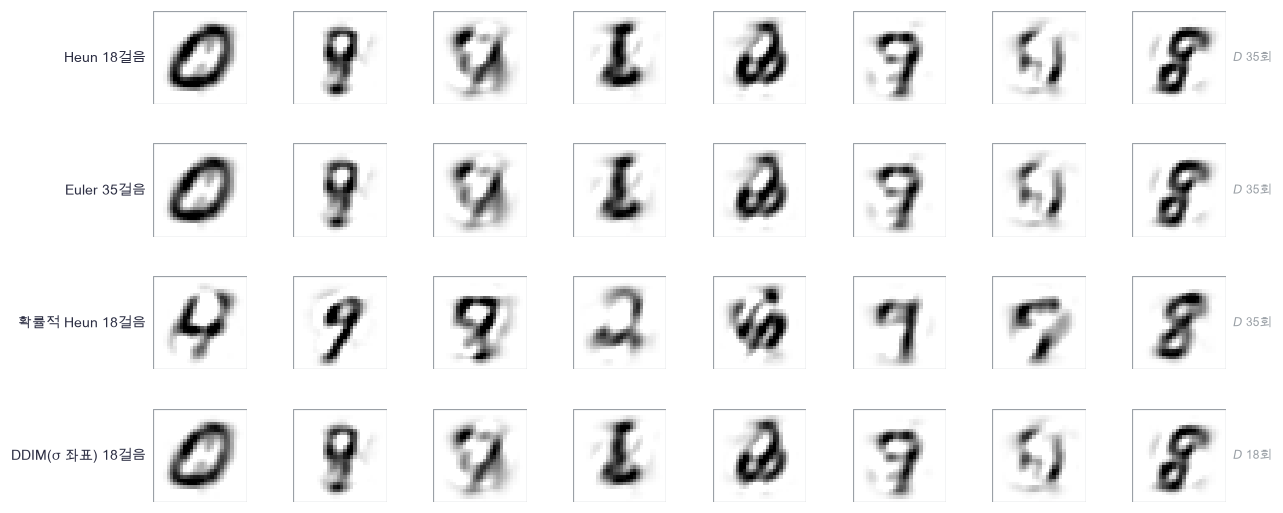

In [64]:
plot_sampler_grid(sampler_rows, sampler_labels,
                  [f"$D$ {calls}회" for calls in sampler_calls])

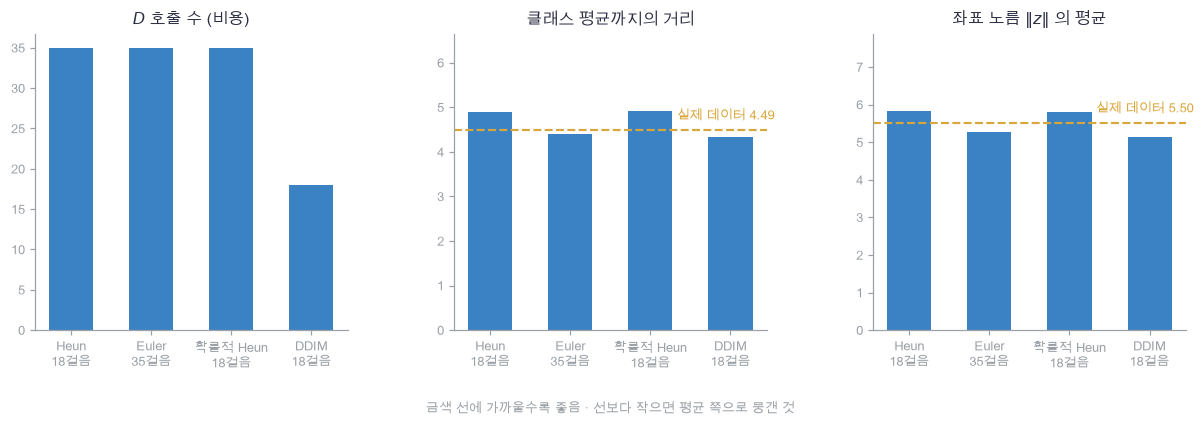

In [65]:
plot_sampler_metrics(sampler_short, sampler_calls, sampler_distances, real_distance, sampler_norms, real_norm)

In [66]:
# 쓰는 것: sampler_labels, sampler_coords (5절 샘플 셀) · sampler_classes, sampler_distances, real_distance (5절 지표 셀)
pair_gaps = {}                                                         # 첫 샘플러와 나머지 사이의 좌표 거리
for label, coords in zip(sampler_labels[1:], sampler_coords[1:]):
    pair_gaps[label] = float(np.sqrt(np.mean(np.sum((coords - sampler_coords[0]) ** 2, axis=1))))
assert min(sampler_classes) >= 8, "네 샘플러 모두 10 개 클래스 중 8 개 이상을 만들어야 합니다"
assert max(abs(distance - real_distance) for distance in sampler_distances) < 0.3 * real_distance, \
    "네 샘플러 모두 최근접 거리가 실제 데이터의 30% 안에 있어야 합니다"
assert pair_gaps["Euler 35걸음"] < pair_gaps["확률적 Heun 18걸음"], "결정적 샘플러끼리가 확률적 샘플러보다 서로 가까워야 합니다"
assert pair_gaps["DDIM(σ 좌표) 18걸음"] < pair_gaps["확률적 Heun 18걸음"], "DDIM 도 같은 ODE 를 푸는 결정적 샘플러입니다"
print("Heun 18걸음과의 좌표 거리:", {label: round(gap, 3) for label, gap in pair_gaps.items()})

Heun 18걸음과의 좌표 거리: {'Euler 35걸음': 0.638, '확률적 Heun 18걸음': 6.122, 'DDIM(σ 좌표) 18걸음': 0.814}


🔍 **확인** · 네 줄의 그림을 세로로 비교하세요. 네 줄 중 **Heun·Euler·DDIM(첫·둘째·넷째 줄)은 같은 자리에 거의 같은 숫자**가 나옵니다. 셋 다 같은 출발 잡음에서 같은 ODE를 푸는 결정적 샘플러이기 때문입니다. 걸음 수도 격자도 다른데 결과가 닮았다는 것이, 1절에서 "세 모델은 같은 좌표 위에 있다"고 한 말의 가장 눈에 보이는 증거입니다.
확률적 Heun(셋째 줄)만 **전혀 다른 숫자**가 나옵니다. 걸음마다 새 잡음을 더했으니 출발 잡음과 도착 그림의 일대일 대응이 깨졌기 때문입니다. 좌표 거리로 재면 Heun과 Euler·DDIM 사이보다 확률적 샘플러와의 거리가 훨씬 멉니다.
지표 막대에서 네 방식 모두 최근접 거리와 좌표 노름이 실제 데이터(금색 선) 근처입니다. 거리가 금색 선보다 **작으면 좋은 것이 아닙니다.** 평균 쪽으로 뭉갠 흐릿한 샘플일수록 클래스 평균에 가깝기 때문입니다. DDIM이 그 방향으로 조금 치우쳐 있는데, $\sigma$가 $2.56$에서만 출발해 큰 잡음 구간을 건너뛴 탓입니다.
확률적 걸음은 이 작은 모델에서는 지표를 좋게 만들지 못했습니다(거리가 실제 데이터보다 조금 더 벌어집니다). 원논문이 보고한 이득은 훨씬 큰 모델과 수백 걸음에서 나오는 것이고, 여기서는 **"무엇을 바꾸는 손잡이인가"**를 보는 것으로 충분합니다. 학습용 작은 문제의 결과이며 실제 벤치마크로 읽지 마세요.

### ✏️ 연습 5 · $\sigma$ 를 도로 올리며 더하는 잡음

$\hat\sigma=\sigma(1+\gamma)$와 $\hat x=x+\sqrt{\hat\sigma^2-\sigma^2}\,n$ 두 줄을 채우세요. $\gamma=0$이면 더하는 잡음이 0이라 4절의 Heun과 같아져야 합니다.

In [67]:

def exercise_churn(x, sigma, gamma, noise):
    """연습 5: σ 를 γ 만큼 올리고 그만큼의 잡음을 더합니다. x, noise: (N, D), sigma·gamma: 숫자 → (x_noisy: (N, D), sigma_hat: 숫자)."""
    assert gamma >= 0, "γ 는 0 이상이어야 합니다"
    assert np.shape(x) == np.shape(noise), "x 와 잡음은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: sigma_hat = σ(1 + γ), x_noisy = x + √(sigma_hat² − σ²) × noise
    ### 힌트: 5절 stochastic_heun 의 sigma_hat 줄과 그 아래 잡음을 더하는 줄입니다.
    raise NotImplementedError
    return x_noisy, sigma_hat

In [68]:

def check_churn(candidate):
    """5절 손계산(σ = 1, γ = 0.2 → σ̂ = 1.2, 잡음 표준편차 0.66332)과 γ = 0 일 때 제자리인지로 검사합니다."""
    # 쓰는 것: (이 검사는 NumPy 만 씁니다)
    ones = np.ones((2, 3))
    noisy_c, hat_c = candidate(np.zeros((2, 3)), 1.0, 0.2, ones)
    np.testing.assert_allclose(hat_c, 1.2)                            # 검산: 손계산 σ̂ = 1 × 1.2
    np.testing.assert_allclose(noisy_c, np.full((2, 3), 0.66332), atol=1e-5)   # 검산: 손계산 √(1.44 − 1) = 0.66332
    same_c, hat_zero = candidate(ones, 2.0, 0.0, ones)
    np.testing.assert_allclose(same_c, ones)                          # 검산: γ = 0 이면 잡음을 더하지 않음
    np.testing.assert_allclose(hat_zero, 2.0)                         # 검산: γ = 0 이면 σ̂ = σ
    big = candidate(np.zeros((40000, 1)), 3.0, 0.5, np.random.default_rng(6005).normal(size=(40000, 1)))[0]
    assert abs(float(big.std()) - np.sqrt(4.5 ** 2 - 3.0 ** 2)) < 0.05, "더한 잡음의 표준편차가 √(σ̂² − σ²) 여야 합니다"
    print("σ 를 올리며 더하는 잡음: 손계산·γ = 0 인 경우와 일치합니다.")

run_check(check_churn, exercise_churn,
          hint="sigma_hat = sigma * (1 + gamma) · x_noisy = x + np.sqrt(sigma_hat ** 2 - sigma ** 2) * noise")

☐ exercise_churn: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: sigma_hat = sigma * (1 + gamma) · x_noisy = x + np.sqrt(sigma_hat ** 2 - sigma ** 2) * noise


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
sigma_hat = sigma * (1 + gamma)
x_noisy = x + np.sqrt(sigma_hat ** 2 - sigma ** 2) * noise
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · VP 좌표를 $\sigma$ 좌표로 (1절)

$\bar\alpha_t$에서 $\sigma(t)=\sqrt{(1-\bar\alpha_t)/\bar\alpha_t}$를 만드는 한 줄을 채우세요. 이 한 줄이 34–35번에서 배운 모든 것을 이 노트북의 좌표로 옮기는 다리입니다.

In [69]:
def exercise_vp_to_sigma(alpha_bar_values):
    """연습 A: VP 좌표를 σ 좌표로. alpha_bar_values: 숫자 하나 또는 (T+1,) → 같은 모양."""
    ab = np.asarray(alpha_bar_values, dtype=float)
    assert np.all(ab > 0), "ᾱ_t 가 0 보다 커야 나눌 수 있습니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: sigma = √((1 − ab)/ab) (ab 와 같은 모양)
    ### 힌트: 1절 vp_to_sigma 의 마지막 한 줄입니다. np.sqrt 를 씁니다.
    raise NotImplementedError
    return sigma

In [70]:
def check_vp_to_sigma(candidate):
    """1절 손계산(ᾱ = 0.64 → 0.75), 본문 스케줄, 그리고 x_t/√ᾱ_t = x₀ + σ ε 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: vp_alpha_bar (1절 계산 셀) · vp_to_sigma (1절)
    np.testing.assert_allclose(candidate(0.64), 0.75)                            # 검산: 손계산 √(0.36/0.64)
    np.testing.assert_allclose(candidate(1.0), 0.0)                              # 검산: ᾱ = 1 이면 아직 잡음이 없음
    np.testing.assert_allclose(candidate(vp_alpha_bar[1:]), vp_to_sigma(vp_alpha_bar[1:]))   # 검산: 본문 스케줄 전체
    rng_check = np.random.default_rng(6001)
    x0_c, eps_c = rng_check.normal(size=(4, 2)), rng_check.normal(size=(4, 2))
    ab_c = vp_alpha_bar[120]
    np.testing.assert_allclose((np.sqrt(ab_c) * x0_c + np.sqrt(1 - ab_c) * eps_c) / np.sqrt(ab_c),   # 검산: 두 좌표가 같은 점
                               x0_c + candidate(ab_c) * eps_c)
    print("VP → σ 변환: 손계산·본문 스케줄·좌표 변환과 일치합니다.")

run_check(check_vp_to_sigma, exercise_vp_to_sigma, hint="sigma = np.sqrt((1 - ab) / ab)")

☐ exercise_vp_to_sigma: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: sigma = np.sqrt((1 - ab) / ab)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
sigma = np.sqrt((1 - ab) / ab)
```

</details>

### ✏️ 연습 B · $c_{skip}$과 $c_{out}$ (2절)

$\sigma$와 $\sigma_{data}$에서 $c_{skip}=\dfrac{\sigma_{data}^2}{\sigma^2+\sigma_{data}^2}$와 $c_{out}=\dfrac{\sigma\sigma_{data}}{\sqrt{\sigma^2+\sigma_{data}^2}}$ 두 줄을 채우세요. $\sigma^2+\sigma_{data}^2$는 `total`로 써 두었습니다. 절 연습 2가 $c_{in}$을 물었다면 여기서는 답을 만드는 두 계수를 봅니다.

In [71]:
def exercise_skip_out(sigma, sigma_data):
    """연습 B: 전처리 계수 c_skip 과 c_out. sigma: 숫자 하나 또는 (N, 1), sigma_data: 숫자 → 같은 모양 둘."""
    assert np.all(np.asarray(sigma) > 0), "σ 는 0 보다 커야 합니다"
    total = sigma ** 2 + sigma_data ** 2                              # σ² + σ_data²
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: c_skip = σ_data²/total, c_out = σ × σ_data/√total
    ### 힌트: 2절 precondition 의 두 줄입니다.
    raise NotImplementedError
    return c_skip, c_out

In [72]:
def check_skip_out(candidate):
    """2절 손계산(0.2, 0.447214), 조건 2 의 c_out² 식, 본문 계수 곡선으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: coef_sigmas, coef_curves (2절 계수 셀) · SIGMA_DATA (📎 규약 셀) · precondition (2절)
    hand_skip_c, hand_out_c = candidate(1.0, 0.5)
    np.testing.assert_allclose([hand_skip_c, hand_out_c], [0.2, 0.447214], atol=1e-6)   # 검산: 손계산 0.25/1.25, 0.5/√1.25
    np.testing.assert_allclose(hand_out_c ** 2, (1 - hand_skip_c) ** 2 * 0.25 + hand_skip_c ** 2 * 1.0)   # 검산: 조건 2
    all_skip_c, all_out_c = candidate(coef_sigmas, SIGMA_DATA)
    np.testing.assert_allclose(all_skip_c, coef_curves["$c_{skip}$"])             # 검산: 2절 그림의 c_skip 곡선
    np.testing.assert_allclose(all_out_c, coef_curves["$c_{out}$"])               # 검산: 2절 그림의 c_out 곡선
    np.testing.assert_allclose(candidate(3.0, 1.5), precondition(3.0, 1.5)[:2])   # 검산: 본문 precondition 과 같음
    print("c_skip 과 c_out: 손계산·조건 2·본문 곡선과 일치합니다.")

run_check(check_skip_out, exercise_skip_out,
          hint="c_skip = sigma_data ** 2 / total · c_out = sigma * sigma_data / np.sqrt(total)")

☐ exercise_skip_out: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: c_skip = sigma_data ** 2 / total · c_out = sigma * sigma_data / np.sqrt(total)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
c_skip = sigma_data ** 2 / total
c_out = sigma * sigma_data / np.sqrt(total)
```

</details>

### ✏️ 연습 C · 학습용 $\sigma$ 뽑기 (3절)

$\ln\sigma\sim\mathcal N(p_{mean},p_{std}^2)$에서 $\sigma$를 `n`개 뽑아 `(n, 1)`로 돌려주는 한 줄을 채우세요. 로그 위에서 정규분포를 뽑고 지수를 취하면 됩니다. 모양을 `(n, 1)`로 두는 이유는 `(n, D)` 데이터에 좌표 축으로 브로드캐스팅하기 위해서입니다.

In [73]:
def exercise_sample_sigma(n, rng, p_mean, p_std):
    """연습 C: 학습용 σ 뽑기. n: 개수, rng: 난수 생성기, p_mean·p_std: 숫자 → (n, 1) 양수."""
    assert p_std > 0, "ln σ 의 표준편차는 0 보다 커야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: sigma = exp(p_mean + p_std × rng.normal(size=(n, 1))) (모양 (n, 1))
    ### 힌트: 3절 sample_sigma 의 한 줄입니다. 표준정규를 (n, 1) 로 뽑아 옮기고 늘린 뒤 np.exp.
    raise NotImplementedError
    return sigma

In [74]:
def check_sample_sigma(candidate):
    """같은 seed 에서 본문 sample_sigma 와 같은 값이 나오는지, 큰 표본의 ln σ 통계가 맞는지 검사합니다."""
    # 쓰는 것: P_MEAN, P_STD (📎 규약 셀) · sample_sigma (3절)
    got = candidate(5, np.random.default_rng(6003), P_MEAN, P_STD)
    assert got.shape == (5, 1), f"모양은 (5, 1) 이어야 하는데 {got.shape} 입니다"
    assert np.all(got > 0), "σ 는 모두 0 보다 커야 합니다"
    np.testing.assert_allclose(got, sample_sigma(5, np.random.default_rng(6003), P_MEAN, P_STD))   # 검산: 본문과 같은 난수열
    many = candidate(200000, np.random.default_rng(6004), -1.2, 1.2)
    assert abs(float(np.log(many).mean()) + 1.2) < 0.02, "ln σ 의 평균이 p_mean = −1.2 여야 합니다"
    assert abs(float(np.log(many).std()) - 1.2) < 0.02, "ln σ 의 표준편차가 p_std = 1.2 여야 합니다"
    print("σ 뽑기: 본문 sample_sigma·ln σ 의 평균과 표준편차와 일치합니다.")

run_check(check_sample_sigma, exercise_sample_sigma, hint="sigma = np.exp(p_mean + p_std * rng.normal(size=(n, 1)))")

☐ exercise_sample_sigma: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: sigma = np.exp(p_mean + p_std * rng.normal(size=(n, 1)))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
sigma = np.exp(p_mean + p_std * rng.normal(size=(n, 1)))
```

</details>

### ✏️ 연습 D · $\rho$ 시간 격자 (4절)

$\sigma_i=\Big(\sigma_{max}^{1/\rho}+\text{ramp}_i\big(\sigma_{min}^{1/\rho}-\sigma_{max}^{1/\rho}\big)\Big)^\rho$ 한 줄을 채우세요. $\text{ramp}$(0에서 1까지)와 마지막 $\sigma_N=0$을 붙이는 줄은 써 두었습니다. 절 연습 4가 Heun 한 걸음을 물었다면, 여기서는 그 걸음을 **어디에 둘지**를 봅니다.

In [75]:
def exercise_sigma_grid(N, rho, sigma_min, sigma_max):
    """연습 D: EDM 시간 격자. N: 걸음 수, rho·sigma_min·sigma_max: 숫자 → (N+1,) 내림차순."""
    assert N >= 2, "걸음 수는 2 이상이어야 합니다"
    assert sigma_max > sigma_min > 0, "σ_max 는 σ_min 보다 크고 둘 다 양수여야 합니다"
    ramp = np.arange(N) / (N - 1)                                     # (N,): 0 … 1
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: grid = (σ_max^(1/ρ) + ramp × (σ_min^(1/ρ) − σ_max^(1/ρ)))^ρ (모양 (N,))
    ### 힌트: 4절 sigma_steps 의 한 줄입니다. 1/ρ 제곱은 ** (1 / rho) 입니다.
    raise NotImplementedError
    return np.concatenate([grid, [0.0]])

In [76]:
def check_sigma_grid(candidate):
    """4절 손계산 두 개와 본문 sigma_steps, 내림차순 여부로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: rho_grids, RHO (4절 격자 셀·📎 규약 셀) · SIGMA_MIN (📎 규약 셀) · mix2_sigma_max (3절) · sigma_steps (4절)
    np.testing.assert_allclose(candidate(3, 1.0, 1.0, 4.0), [4.0, 2.5, 1.0, 0.0])    # 검산: 손계산 ρ = 1
    np.testing.assert_allclose(candidate(3, 2.0, 1.0, 4.0), [4.0, 2.25, 1.0, 0.0])   # 검산: 손계산 ρ = 2
    np.testing.assert_allclose(candidate(10, RHO, SIGMA_MIN, mix2_sigma_max), rho_grids[RHO])   # 검산: 4절 그림의 ρ = 7 격자
    np.testing.assert_allclose(candidate(18, RHO, 0.002, 80.0), sigma_steps(18))     # 검산: 본문 sigma_steps
    made = candidate(20, 3.0, 0.01, 50.0)
    assert np.all(np.diff(made) < 0), "격자는 큰 σ 에서 작은 σ 로 내려가야 합니다"
    print("σ 격자: 손계산 두 개·본문 sigma_steps 와 일치합니다.")

run_check(check_sigma_grid, exercise_sigma_grid,
          hint="grid = (sigma_max ** (1 / rho) + ramp * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho")

☐ exercise_sigma_grid: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: grid = (sigma_max ** (1 / rho) + ramp * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
grid = (sigma_max ** (1 / rho) + ramp * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
```

</details>

### 🔍 완성 예제 · $\rho$를 바꾸고, $\sigma_{data}$를 틀리게 넣어 보기

설계 공간을 만들어 두면 **하나씩 바꿔 볼 수 있습니다.** 두 가지를 바꿉니다.

1. **$\rho$**: 정확한 $D$로 Heun을 돌려 $\rho=1,3,7$의 오차를 비교합니다. 적분기도 모델도 그대로이고 걸음의 자리만 바뀝니다.
2. **$\sigma_{data}$**: 2차원 혼합의 실제 표준편차는 $1.62$입니다. 여기에 $0.5$(논문의 이미지 값)와 $4.0$을 넣어 다시 학습하고, 정확한 $D$와의 격자 오차를 비교합니다. 데이터와 학습 코드는 한 줄도 바꾸지 않고 **전처리 계수만** 달라집니다.

$\sigma_{data}$를 바꾸면 손실값 자체는 서로 비교할 수 없습니다. $\lambda(\sigma)=1/c_{out}^2$가 달라져 **다른 자로 잰 값**이 되기 때문입니다. 그래서 정답 $D$와의 격자 오차로 비교합니다.

In [77]:
# 쓰는 것: converge_start, converge_reference (4절 기준 셀) · sigma_steps, heun_sample (4절) · mix2_denoiser (📎 혼합 셀) · mix2_sigma_max, RHO (3절·📎 규약 셀)
variant_N = [5, 10, 20, 40]
variant_rho_errors = {f"$\\rho = {rho:g}$": [] for rho in [1.0, 3.0, RHO]}
for N in variant_N:
    for rho in [1.0, 3.0, RHO]:
        final = heun_sample(converge_start.copy(), sigma_steps(N, rho, sigma_max=mix2_sigma_max), mix2_denoiser)
        variant_rho_errors[f"$\\rho = {rho:g}$"].append(float(np.sqrt(np.mean(np.sum((final - converge_reference) ** 2, axis=1)))))
assert variant_rho_errors["$\\rho = 1$"][1] > variant_rho_errors["$\\rho = 7$"][1], "균등 격자(ρ = 1)는 10걸음에서 ρ = 7 보다 나빠야 합니다"
for name, values in variant_rho_errors.items():
    print(f"{name:12s}", np.array(values).round(5))

$\rho = 1$   [0.9072 0.2552 0.0577 0.0159]
$\rho = 3$   [0.4034 0.0663 0.0139 0.0032]
$\rho = 7$   [0.7041 0.1074 0.0212 0.0047]


In [78]:
# 쓰는 것: mixture_X0, mixture_p, grid_points, grid_after (3절 학습 셀) · mix2_sigma_data (📎 검산 셀) · mix2_p_mean (3절) · train_edm, edm_denoise (3절) · mix2_denoiser (📎 혼합 셀)
variant_labels = [f"{mix2_sigma_data:.2f} (실제)", "0.5 (논문의 이미지 값)", "4.0 (너무 큼)"]
variant_models = {mix2_sigma_data: mixture_p}                          # 실제 값은 3절에서 학습한 모델을 그대로 씁니다
for sigma_data in [0.5, 4.0]:
    variant_models[sigma_data] = train_edm(mixture_X0, 3000, 3510, sigma_data, mix2_p_mean)[0]
variant_grid_errors = [float(np.mean(grid_after))]                     # 실제 값의 평균 격자 오차 (3절에서 잰 것)
for sigma_data in [0.5, 4.0]:
    errors = [float(np.sqrt(np.mean(np.sum((edm_denoise(grid_points, sigma, variant_models[sigma_data], sigma_data)
                                            - mix2_denoiser(grid_points, sigma)) ** 2, axis=1)))) for sigma in [0.1, 0.5, 2.0]]
    variant_grid_errors.append(float(np.mean(errors)))
assert variant_grid_errors[0] == min(variant_grid_errors), "데이터의 실제 표준편차를 넣었을 때 격자 오차가 가장 작아야 합니다"
print("σ_data 별 평균 격자 RMSE:", {label: round(error, 4) for label, error in zip(variant_labels, variant_grid_errors)})

σ_data 별 평균 격자 RMSE: {'1.62 (실제)': 0.1251, '0.5 (논문의 이미지 값)': 0.1317, '4.0 (너무 큼)': 0.1761}


In [79]:
# 쓰는 것: coef_sigmas (2절 계수 셀) · mix2_sigma_data (📎 검산 셀)
variant_skip_curves = {label: mix2_sigma_data ** 2 / (coef_sigmas ** 2 + mix2_sigma_data ** 2)
                       for label in [f"$\\sigma_{{data}} = {mix2_sigma_data:.2f}$"]}
for sigma_data in [0.5, 4.0]:
    variant_skip_curves[f"$\\sigma_{{data}} = {sigma_data:g}$"] = sigma_data ** 2 / (coef_sigmas ** 2 + sigma_data ** 2)
print("c_skip 이 0.5 가 되는 σ:", [round(sigma_data, 2) for sigma_data in [mix2_sigma_data, 0.5, 4.0]])

c_skip 이 0.5 가 되는 σ: [1.62, 0.5, 4.0]


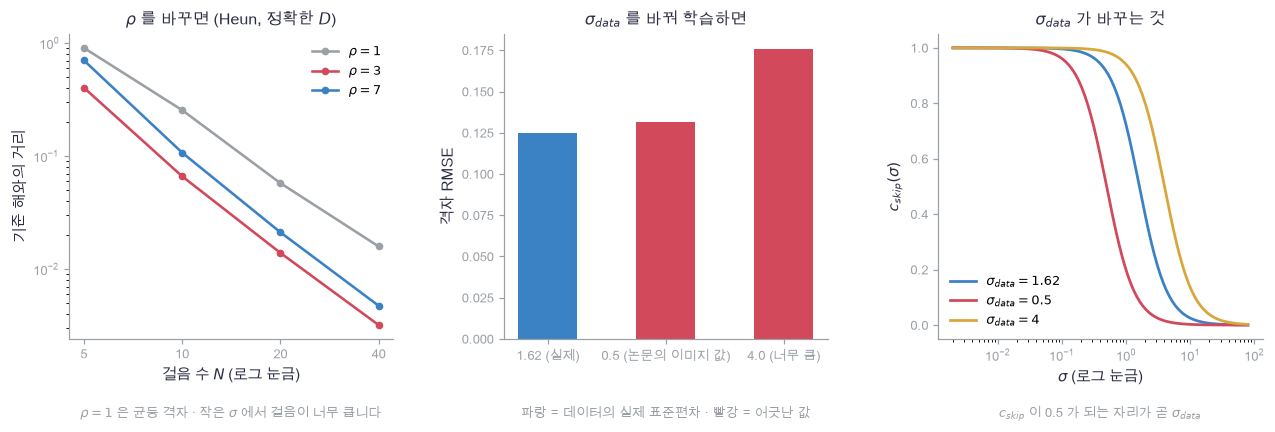

In [80]:
plot_variants(variant_N, variant_rho_errors, variant_labels, variant_grid_errors, coef_sigmas, variant_skip_curves)

🔍 **확인** · 왼쪽에서 $\rho=1$(균등 격자)이 뚜렷하게 나쁩니다. 10걸음일 때 $\rho=7$보다 오차가 두 배 넘습니다. 균등 격자는 마지막 한 걸음에서 $\sigma$를 $1.11$에서 $0.002$까지 한 번에 건너뛰는데, 바로 그 구간에서 $D$가 가장 빠르게 휘기 때문입니다.
그런데 이 장난감 문제에서는 $\rho=3$이 $\rho=7$보다 조금 낫습니다. **$\rho=7$은 이미지에서 고른 값이지 어디서나 최적인 값이 아닙니다.** 설계 공간을 만들어 두면 이런 것을 실험으로 확인할 수 있습니다.
가운데에서 $\sigma_{data}$를 데이터의 실제 표준편차로 둔 쪽(파랑)이 가장 작습니다. $4.0$을 넣으면 눈에 띄게 나빠집니다. 오른쪽 곡선이 이유를 보여 줍니다. $c_{skip}$이 $0.5$를 지나는 자리가 곧 $\sigma_{data}$이므로, $\sigma_{data}$를 크게 잡으면 큰 $\sigma$에서도 "입력을 거의 그대로 흘려보내는" 설정이 되어 신경망이 고칠 몫이 줄어듭니다.
$0.5$를 넣은 경우는 실제 값과 큰 차이가 없습니다. 전처리는 **대략만 맞으면 되는** 장치입니다. 다만 손실값은 $\sigma_{data}$마다 다른 자로 잰 것이라 비교할 수 없다는 점만 기억하세요. 학습용 작은 문제의 결과입니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** VE와 VP가 왜 같은 것의 다른 배율인지, $\sigma$ 좌표에서 score·$D$·$\hat\epsilon$이 어떻게 서로 바뀌는지 말할 수 있나요? → 1절
- **수식:** $c_{in}$·$c_{skip}$·$c_{out}$을 "입력 분산 1", "타깃 분산 1", "$c_{out}$ 최소"라는 조건에서 유도하고, $\lambda(\sigma)=1/c_{out}^2$가 왜 그 값인지 쓸 수 있나요? → 2·3절
- **구현:** $\rho$ 격자와 Heun 한 걸음을 직접 쓰고, 정확한 $D$로 1차·2차 수렴을 확인할 수 있나요? → 4절
- **변형:** 걸음을 늘려도 오차가 줄지 않을 때 적분기와 모델 중 어느 쪽 문제인지 가려낼 수 있나요? $\rho$나 $\sigma_{data}$를 바꾸면 무엇이 달라지나요? → 4절·완성 예제

다음 걸음은 **36 flow matching**입니다. 이 노트북에서 "샘플링은 ODE 풀기"까지 왔으니, 남은 질문은 "그 ODE의 기울기를 꼭 $D$를 거쳐 만들어야 하는가"입니다. flow matching은 잡음에서 데이터까지 가는 **속도장을 바로 회귀**로 배우고, 4절의 Euler·Heun을 그대로 씁니다. 아직 노트북으로 만들지 않았습니다.

📎 [Karras 등, 2022 (EDM)](https://arxiv.org/abs/2206.00364)이 이 노트북의 $\sigma$ 통일·preconditioning 계수·$\lambda(\sigma)$·$\rho$ 격자·Heun 샘플러를 한 편으로 정리했습니다(표 1과 알고리즘 1·2). 확률 흐름 ODE는 [Song 등, 2021](https://arxiv.org/abs/2011.13456)에서 왔고, Tweedie 항등은 [Efron, 2011](https://doi.org/10.1198/jasa.2011.tm11181)이 정리한 고전입니다. 이 노트북의 혼합 예제와 32차원 좌표 모델은 설명을 위해 새로 구성한 것이며 원논문의 재현 실험이 아닙니다.